Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
Platform: Linux-6.6.56+-x86_64-with-glibc2.35
PyTorch: 2.6.0+cu124
CUDA available: True
CUDA device count: 2
CUDA device name (0): Tesla T4

Found classes (folders): ['cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic']

Scanning images (this may take a minute)...


Scanning plastic: 100%|██████████| 4000/4000 [00:33<00:00, 118.32file/s]



Summary:
 Total images recorded: 23998
  cardboard: 3999
  clothes: 4000
  glass: 4000
  metal: 4000
  paper: 3999
  plastic: 4000

 Number of corrupted/unreadable images found: 2
 Showing up to 10 corrupted file examples:
  /kaggle/input/garbage-trashbox-hybrid-dataset/cardboard/cardboard_2629.jpg | error: cannot identify image file '/kaggle/input/garbage-trashbox-hybrid-dataset/cardboard/cardboard_2629.jpg'
  /kaggle/input/garbage-trashbox-hybrid-dataset/paper/paper_2214.jpg | error: cannot identify image file '/kaggle/input/garbage-trashbox-hybrid-dataset/paper/paper_2214.jpg'

 Image size stats (width x height):
  min: 69 x 71
  max: 10500 x 6283

  Top image sizes (w,h) and counts:
(512, 384)    3302
(400, 533)    1848
(225, 225)     890
(400, 534)     692
(300, 300)     688
Name: count, dtype: int64

Displaying one sample image per class...


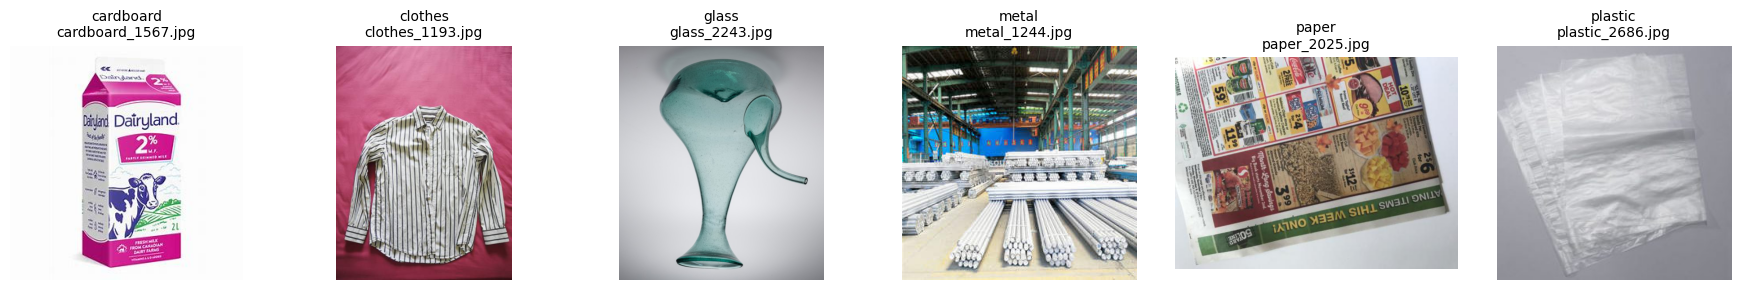


Manifest saved to: /kaggle/working/manifest.csv
Done. Paste the printed summary (class counts, corrupted count) and any errors here, and I'll give the next snippet (dataset pipeline + augmentations).


In [ ]:

DATA_DIR = "/kaggle/input/garbage-trashbox-hybrid-dataset"  

import sys, platform
from pathlib import Path
from PIL import Image, ImageFile
import pandas as pd
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True

print("Python:", sys.version.splitlines()[0])
print("Platform:", platform.platform())

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("CUDA device count:", torch.cuda.device_count())
        try:
            print("CUDA device name (0):", torch.cuda.get_device_name(0))
        except:
            pass
except Exception as e:
    print("PyTorch not available or failed to import:", e)


data_root = Path(DATA_DIR)
if not data_root.exists():
    raise FileNotFoundError(f"DATA_DIR does not exist: {DATA_DIR}")


IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp', '.gif'}

classes = sorted([p.name for p in data_root.iterdir() if p.is_dir()])
print("\nFound classes (folders):", classes)


records = []
corrupted = []
sizes = []
print("\nScanning images (this may take a minute)...")
for cls in classes:
    cls_path = data_root / cls
    for p in tqdm(sorted(cls_path.iterdir()), desc=f"Scanning {cls}", unit="file"):
        if p.suffix.lower() not in IMG_EXTS:
            continue
        try:
            
            with Image.open(p) as img:
                img.verify()  
            with Image.open(p) as img:
                sizes.append(img.size)  
            records.append((str(p.resolve()), cls))
        except Exception as e:
            corrupted.append((str(p.resolve()), str(e)))


df = pd.DataFrame(records, columns=["image_path", "label"])
manifest_path = "/kaggle/working/manifest.csv"
df.to_csv(manifest_path, index=False)


print("\nSummary:")
total_images = len(df)
print(" Total images recorded:", total_images)
for cls in classes:
    c = int((df['label'] == cls).sum())
    print(f"  {cls}: {c}")

print("\n Number of corrupted/unreadable images found:", len(corrupted))
if corrupted:
    print(" Showing up to 10 corrupted file examples:")
    for item in corrupted[:10]:
        print(" ", item[0], "| error:", item[1])


if sizes:
    widths, heights = zip(*sizes)
    print("\n Image size stats (width x height):")
    print("  min:", min(widths), "x", min(heights))
    print("  max:", max(widths), "x", max(heights))
    
    size_counts = pd.Series(sizes).value_counts().head(5)
    print("\n  Top image sizes (w,h) and counts:")
    print(size_counts)


print("\nDisplaying one sample image per class...")
n = len(classes)
fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
if n == 1:
    axes = [axes]
for ax, cls in zip(axes, classes):
    sample = df[df['label']==cls].sample(1).iloc[0]
    img = Image.open(sample['image_path']).convert("RGB")
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{cls}\n{os.path.basename(sample['image_path'])}", fontsize=10)
plt.tight_layout()
plt.show()

print("\nManifest saved to:", manifest_path)
print("Done. Paste the printed summary (class counts, corrupted count) and any errors here, and I'll give the next snippet (dataset pipeline + augmentations).")


In [ ]:
import pandas as pd


manifest_path = "/kaggle/working/manifest.csv"
df = pd.read_csv(manifest_path)


corrupted_files = [
    "/kaggle/input/garbage-trashbox-hybrid-dataset/cardboard/cardboard_2629.jpg",
    "/kaggle/input/garbage-trashbox-hybrid-dataset/paper/paper_2214.jpg"
]

df_clean = df[~df['image_path'].isin(corrupted_files)].reset_index(drop=True)

clean_manifest_path = "/kaggle/working/manifest_clean.csv"
df_clean.to_csv(clean_manifest_path, index=False)

print("Original manifest size:", len(df))
print("Cleaned manifest size:", len(df_clean))
print("Corrupted files removed:", len(df) - len(df_clean))
print("Clean manifest saved to:", clean_manifest_path)


Original manifest size: 23998
Cleaned manifest size: 23998
Corrupted files removed: 0
Clean manifest saved to: /kaggle/working/manifest_clean.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

manifest_path = "/kaggle/working/manifest_clean.csv"
df = pd.read_csv(manifest_path)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)

train_df.to_csv("/kaggle/working/train.csv", index=False)
val_df.to_csv("/kaggle/working/val.csv", index=False)
test_df.to_csv("/kaggle/working/test.csv", index=False)

print("Dataset split completed ✅")
print(f"Train set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")

print("\nClass distribution (Train):")
print(train_df['label'].value_counts())

print("\nClass distribution (Validation):")
print(val_df['label'].value_counts())

print("\nClass distribution (Test):")
print(test_df['label'].value_counts())


Dataset split completed ✅
Train set: 16798 images
Validation set: 3600 images
Test set: 3600 images

Class distribution (Train):
label
plastic      2800
clothes      2800
glass        2800
metal        2800
paper        2799
cardboard    2799
Name: count, dtype: int64

Class distribution (Validation):
label
metal        600
clothes      600
plastic      600
glass        600
cardboard    600
paper        600
Name: count, dtype: int64

Class distribution (Test):
label
glass        600
paper        600
clothes      600
metal        600
cardboard    600
plastic      600
Name: count, dtype: int64


Datasets and DataLoaders ready ✅
Train batches: 525
Val batches: 113
Test batches: 113
Batch shape: torch.Size([32, 3, 224, 224]) torch.Size([32])


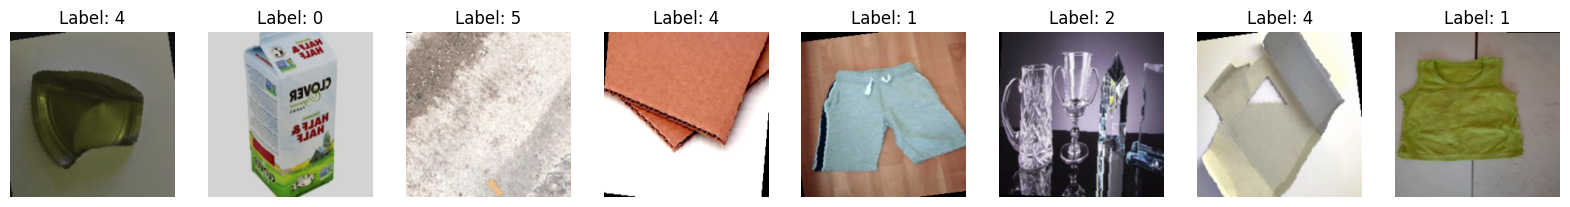

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd


IMG_SIZE = 224  

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  
                         std=[0.229, 0.224, 0.225])  
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


class WasteDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.classes = sorted(self.data['label'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['image_path']
        label = self.data.iloc[idx]['label']
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.class_to_idx[label]


BATCH_SIZE = 32  

train_dataset = WasteDataset("/kaggle/working/train.csv", transform=train_transform)
val_dataset   = WasteDataset("/kaggle/working/val.csv", transform=val_test_transform)
test_dataset  = WasteDataset("/kaggle/working/test.csv", transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Datasets and DataLoaders ready ✅")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


import matplotlib.pyplot as plt
import numpy as np


def imshow(img_tensor, title):
    img = img_tensor.numpy().transpose((1, 2, 0))  
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")


images, labels = next(iter(train_loader))
print("Batch shape:", images.shape, labels.shape)

fig, axes = plt.subplots(1, 8, figsize=(20, 4))
for i in range(8):
    plt.sca(axes[i])
    imshow(images[i].cpu(), f"Label: {labels[i].item()}")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from transformers import ViTModel

class ResNet50_ViT_Fusion(nn.Module):
    def __init__(self, num_classes=6, freeze_backbones=True):
        super(ResNet50_ViT_Fusion, self).__init__()
        
        self.resnet = models.resnet50(pretrained=True)
        self.resnet.fc = nn.Identity()   
        
        
        self.vit = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
        self.vit_hidden = self.vit.config.hidden_size   
        
        fusion_dim = 2048 + self.vit_hidden
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, num_classes)
        )

       
        if freeze_backbones:
            for param in self.resnet.parameters():
                param.requires_grad = False
            for param in self.vit.parameters():
                param.requires_grad = False

    def forward(self, x):
        resnet_feat = self.resnet(x)  
        vit_out = self.vit(pixel_values=x).pooler_output  
        fused = torch.cat((resnet_feat, vit_out), dim=1) 
        out = self.classifier(fused)
        return out



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50_ViT_Fusion(num_classes=6, freeze_backbones=True).to(device)

print("Hybrid model with frozen backbones ready ✅")


2025-09-14 09:12:55.706832: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757841176.063207      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757841176.175156      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Hybrid model with frozen backbones ready ✅


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

print("Training setup ready ✅")


Training setup ready ✅


In [ ]:
from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    best_acc = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        model.train()
        running_loss, running_corrects = 0.0, 0
        for inputs, labels in tqdm(train_loader, desc="Training", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc.item())

        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc="Validation", leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_loss /= len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc.item())

        print(f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        scheduler.step(val_loss)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
            print("✅ Best model updated and saved.")

    print(f"\nTraining complete. Best Val Accuracy: {best_acc:.4f}")
    return history


history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20)



Epoch 1/20
------------------------------


Training:   0%|          | 0/525 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   2%|▏         | 13/525 [00:08<03:37,  2.36it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  50%|█████     | 57/113 [00:30<00:29,  1.89it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  73%|███████▎  | 82/113 [00:43<00:16,  1.88it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.5383 Acc: 0.8087
Val   Loss: 0.3218 Acc: 0.8878
✅ Best model updated and saved.

Epoch 2/20
------------------------------


Training:  11%|█         | 59/525 [00:33<04:13,  1.84it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  12%|█▏        | 63/525 [00:35<04:11,  1.83it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  50%|█████     | 57/113 [00:30<00:29,  1.89it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  73%|███████▎  | 82/113 [00:43<00:16,  1.89it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.3794 Acc: 0.8633
Val   Loss: 0.3143 Acc: 0.8864

Epoch 3/20
------------------------------


...

Train Loss: 0.1863 Acc: 0.9335
Val   Loss: 0.2163 Acc: 0.9325

Epoch 19/20
------------------------------


Training:   3%|▎         | 18/525 [00:10<04:35,  1.84it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  49%|████▉     | 259/525 [02:20<02:23,  1.85it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  50%|█████     | 57/113 [00:30<00:29,  1.88it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  73%|███████▎  | 82/113 [00:43<00:16,  1.89it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.1813 Acc: 0.9363
Val   Loss: 0.1915 Acc: 0.9406
✅ Best model updated and saved.

Epoch 20/20
------------------------------


Training:  19%|█▉        | 100/525 [00:54<03:49,  1.85it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  72%|███████▏  | 379/525 [03:25<01:18,  1.85it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  50%|█████     | 57/113 [00:30<00:29,  1.88it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  73%|███████▎  | 82/113 [00:44<00:16,  1.88it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.1691 Acc: 0.9406
Val   Loss: 0.1941 Acc: 0.9419
✅ Best model updated and saved.

Training complete. Best Val Accuracy: 0.9419


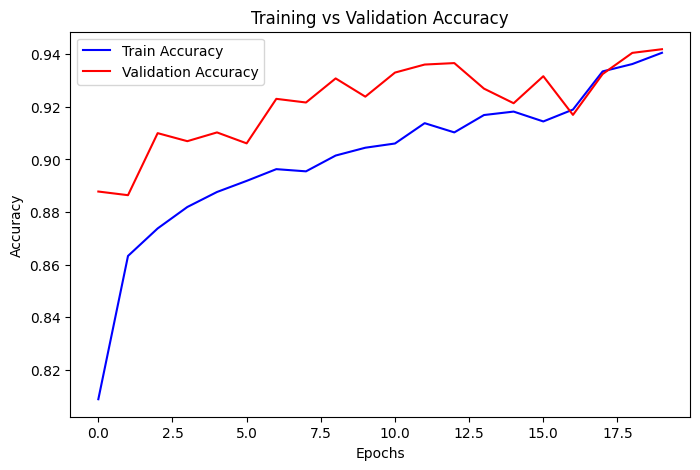

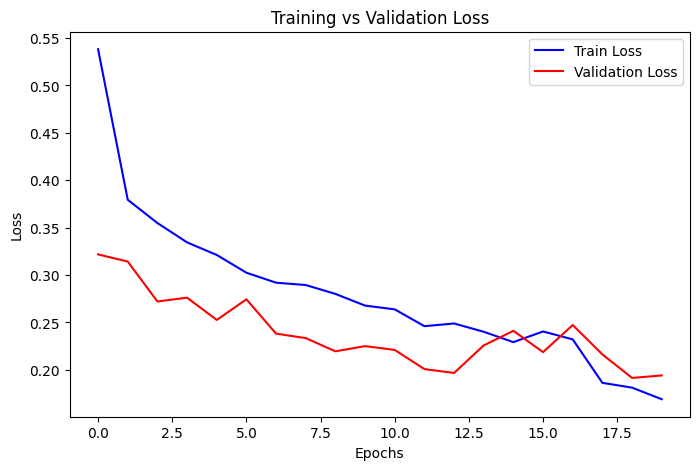

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="Train Accuracy", color="blue")
plt.plot(history["val_acc"], label="Validation Accuracy", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss", color="blue")
plt.plot(history["val_loss"], label="Validation Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test Accuracy: 0.9353

Classification Report:

              precision    recall  f1-score   support

   cardboard     0.9190    0.9267    0.9228       600
     clothes     1.0000    0.9917    0.9958       600
       glass     0.9606    0.9350    0.9476       600
       metal     0.9068    0.9733    0.9389       600
       paper     0.9164    0.8767    0.8961       600
     plastic     0.9114    0.9083    0.9098       600

    accuracy                         0.9353      3600
   macro avg     0.9357    0.9353    0.9352      3600
weighted avg     0.9357    0.9353    0.9352      3600



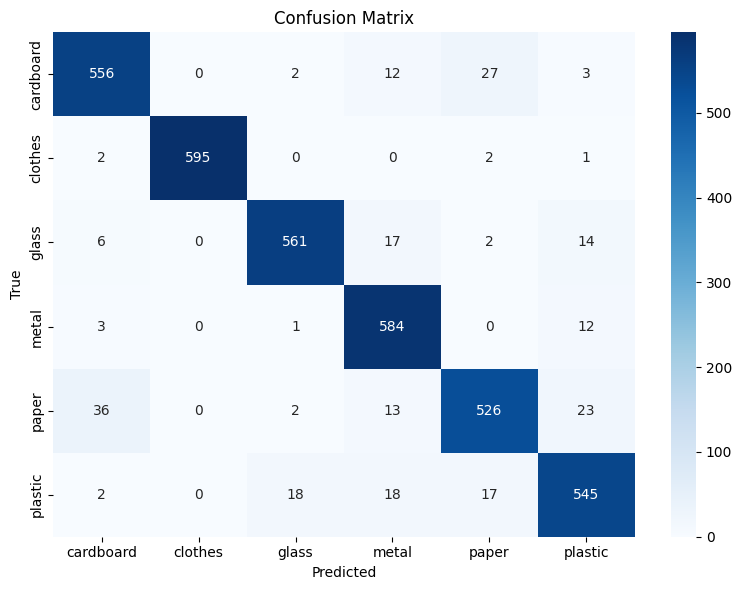


Per-class accuracy:
       class  support  accuracy
0  cardboard      600  0.926667
1    clothes      600  0.991667
2      glass      600  0.935000
3      metal      600  0.973333
4      paper      600  0.876667
5    plastic      600  0.908333


In [ ]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.to(device)
model.eval()


try:
    class_names = train_dataset.classes
except:
    class_names = ['cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic']

idx_to_class = {i: c for i, c in enumerate(class_names)}

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)
per_class_df = pd.DataFrame({
    "class": class_names,
    "support": cm.sum(axis=1),
    "accuracy": per_class_acc
})
print("\nPer-class accuracy:")
print(per_class_df)


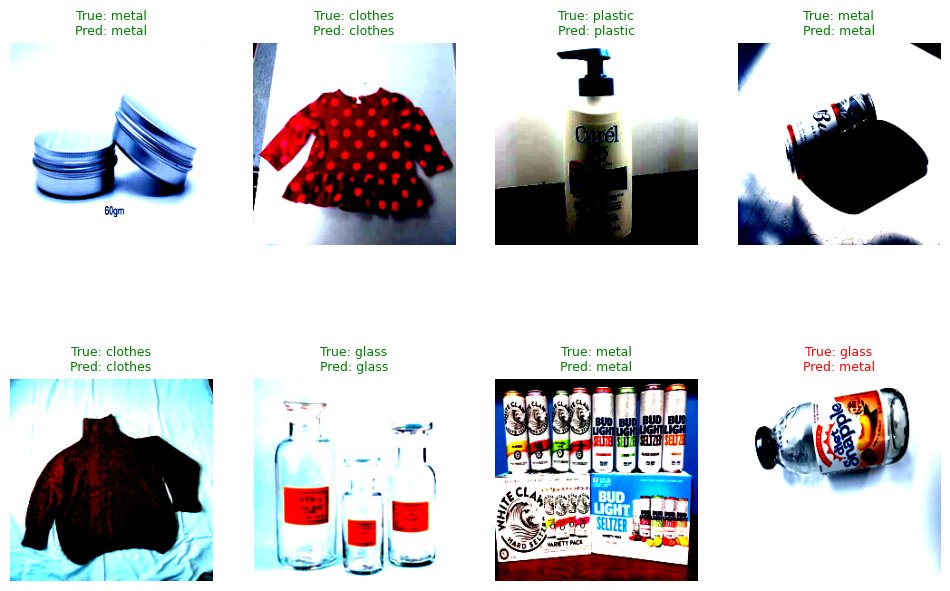

In [ ]:
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')



model.eval()
inputs, labels = next(iter(val_loader))
inputs, labels = inputs.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(12,8))
for i in range(8):  
    ax = plt.subplot(2,4,i+1)
    imshow(inputs[i])
    ax.set_title(
        f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}",
        fontsize=9,
        color=("green" if preds[i]==labels[i] else "red")
    )
plt.show()

In [ ]:
def predict_image_with_recycling(image_path):
    model.eval()
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    
    image = Image.open(image_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)
    
    predicted_class = class_names[predicted.item()]
    recycle_info = recycling_guide[predicted_class]
    
    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(f"Predicted: {predicted_class}", fontsize=14, weight="bold")
    
    ax.text(0.5, -0.1, recycle_info["method"], ha="center", fontsize=12, 
            weight="bold", color="green", transform=ax.transAxes)
    ax.text(0.5, -0.22, recycle_info["process"], ha="center", fontsize=9, 
            style="italic", wrap=True, transform=ax.transAxes)
    
    plt.subplots_adjust(bottom=0.25)
    plt.show()
    
    return predicted_class, recycle_info


In [14]:
recycling_guide = {
    "cardboard": {
        "method": "📦 Shredding & pulping to make new paper products.",
        "process": "Flatten the cardboard, keep it dry, and place it in the recycling bin. Avoid greasy or wet cardboard."
    },
    "clothes": {
        "method": "👕 Fiber recovery for new textiles or insulation materials.",
        "process": "Donate if wearable. Otherwise, take to textile recycling centers. Avoid putting in general waste bins."
    },
    "glass": {
        "method": "🍾 Melting & remolding into new glass products.",
        "process": "Rinse bottles/jars and remove lids. Place in glass recycling bin. Avoid mixing broken glass with regular recyclables."
    },
    "metal": {
        "method": "⚙️ Melting & reshaping into new metal items.",
        "process": "Rinse cans, tins, and foil. Place them in metal recycling. Large metal items should go to scrap yards."
    },
    "paper": {
        "method": "📄 Pulping & remanufacturing into recycled paper products.",
        "process": "Keep paper dry and clean. Recycle newspapers, magazines, and office paper. Avoid greasy or plastic-coated paper."
    },
    "plastic": {
        "method": "🛍 Shredding, melting & remolding into new plastic products.",
        "process": "Check recycling codes. Clean bottles/containers before recycling. Some plastics may need to go to special recycling centers."
    }
}


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


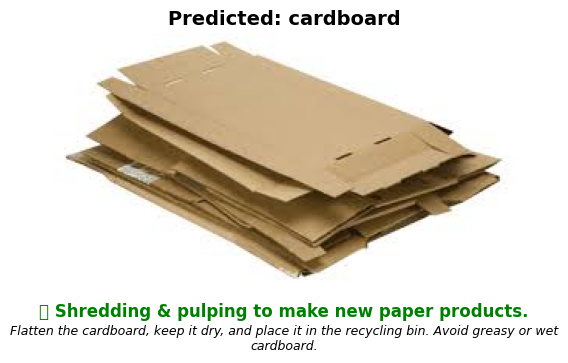

In [24]:
predicted_class, recycle_info = predict_image_with_recycling(
    "/kaggle/input/sample-waste-images/download (2).jpg"
)


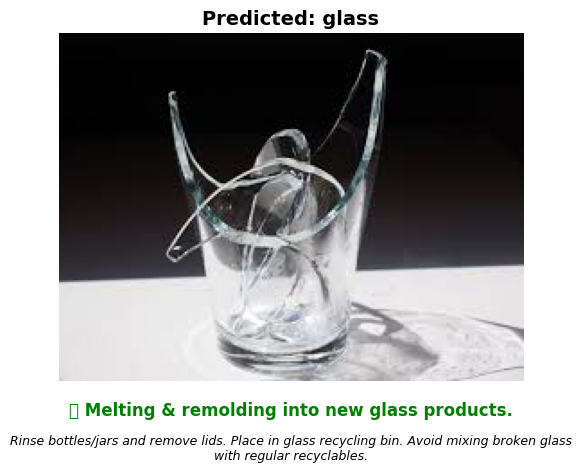

In [26]:
predicted_class, recycle_info = predict_image_with_recycling(
    "/kaggle/input/sample-waste-images/download (14).jpg"
)


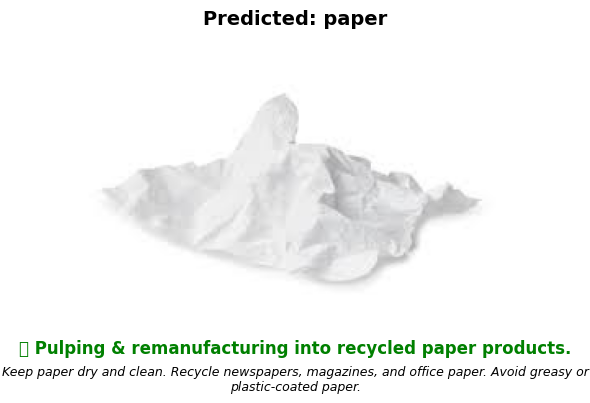

In [30]:
predicted_class, recycle_info = predict_image_with_recycling(
    "/kaggle/input/sample-waste-images/download (4).jpg"
)


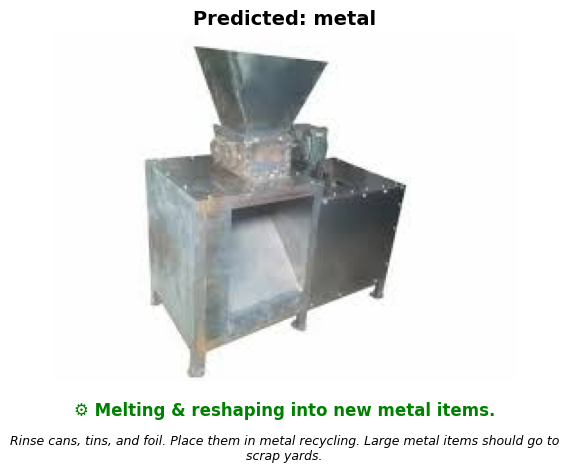

In [44]:
predicted_class, recycle_info = predict_image_with_recycling(
    "/kaggle/input/sample-waste-images/images (2).jpg"
)


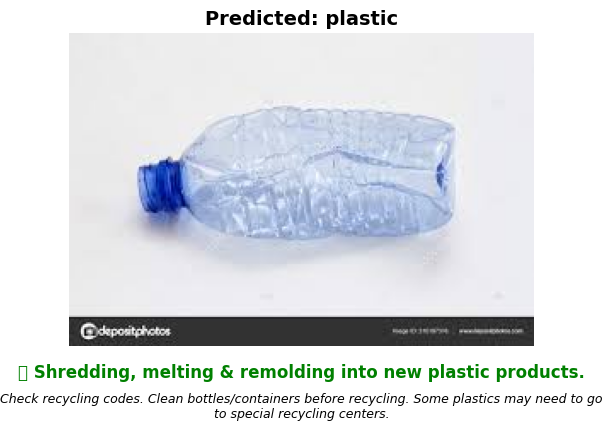

In [35]:
predicted_class, recycle_info = predict_image_with_recycling(
    "/kaggle/input/sample-waste-images/download.jpg"
)


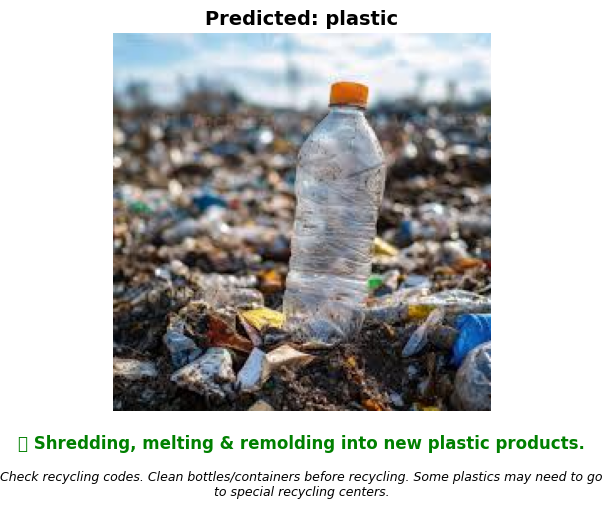

In [42]:
predicted_class, recycle_info = predict_image_with_recycling(
    "/kaggle/input/sample-waste-images/images (6).jpg"
)


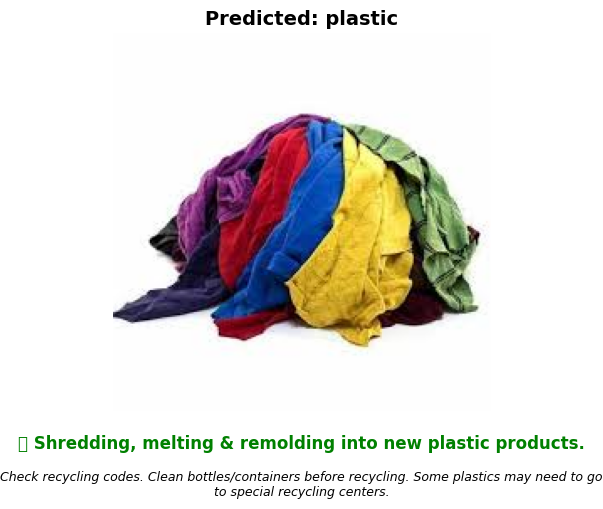

In [45]:
predicted_class, recycle_info = predict_image_with_recycling(
    "/kaggle/input/sample-waste-images/download (11).jpg"
)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

print("Starting Phase 2A: Progressive Fine-tuning")
print("="*50)

model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
print("✅ Loaded Phase 1 best model")


def unfreeze_vit_top_layers(model, num_layers_to_unfreeze=3):
    """
    Unfreeze the last few transformer blocks of ViT
    """
    for param in model.resnet.parameters():
        param.requires_grad = False
    
    total_vit_layers = len(model.vit.encoder.layer)
    print(f"Total ViT layers: {total_vit_layers}")
    
    for param in model.vit.parameters():
        param.requires_grad = False
    
    layers_to_unfreeze = total_vit_layers - num_layers_to_unfreeze
    for i in range(layers_to_unfreeze, total_vit_layers):
        print(f"Unfreezing ViT layer {i}")
        for param in model.vit.encoder.layer[i].parameters():
            param.requires_grad = True
    
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    if hasattr(model.vit, 'pooler') and model.vit.pooler is not None:
        for param in model.vit.pooler.parameters():
            param.requires_grad = True
    
    print(f"✅ Unfroze top {num_layers_to_unfreeze} ViT layers + classifier")

unfreeze_vit_top_layers(model, num_layers_to_unfreeze=3)


trainable_params = 0
frozen_params = 0

print("\nTrainable parameters by component:")
print("-" * 40)

resnet_trainable = sum(p.numel() for p in model.resnet.parameters() if p.requires_grad)
resnet_frozen = sum(p.numel() for p in model.resnet.parameters() if not p.requires_grad)
print(f"ResNet - Trainable: {resnet_trainable:,}, Frozen: {resnet_frozen:,}")

vit_trainable = sum(p.numel() for p in model.vit.parameters() if p.requires_grad)
vit_frozen = sum(p.numel() for p in model.vit.parameters() if not p.requires_grad)
print(f"ViT - Trainable: {vit_trainable:,}, Frozen: {vit_frozen:,}")

classifier_trainable = sum(p.numel() for p in model.classifier.parameters() if p.requires_grad)
print(f"Classifier - Trainable: {classifier_trainable:,}")

total_trainable = resnet_trainable + vit_trainable + classifier_trainable
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable: {total_trainable:,} ({100*total_trainable/total_params:.1f}%)")
print(f"Total parameters: {total_params:,}")



Starting Phase 2A: Progressive Fine-tuning
✅ Loaded Phase 1 best model
Total ViT layers: 12
Unfreezing ViT layer 9
Unfreezing ViT layer 10
Unfreezing ViT layer 11
✅ Unfroze top 3 ViT layers + classifier

Trainable parameters by component:
----------------------------------------
ResNet - Trainable: 0, Frozen: 23,508,032
ViT - Trainable: 21,854,208, Frozen: 64,535,040
Classifier - Trainable: 2,890,758

Total trainable: 24,744,966 (21.9%)
Total parameters: 112,788,038


In [ ]:
def setup_discriminative_optimizer(model):
    """
    Different learning rates for different components
    """
    vit_params = []
    classifier_params = []
    
    for param in model.vit.parameters():
        if param.requires_grad:
            vit_params.append(param)
    
    for param in model.classifier.parameters():        classifier_params.append(param
    
    param_groups = [
        {'params': vit_params, 'lr': 3e-5, 'name': 'vit'},
        {'params': classifier_params, 'lr': 1e-4, 'name': 'classifier'}
    ]
    
    optimizer = optim.AdamW(param_groups, weight_decay=0.01)
    
    print("✅ Discriminative learning rates setup:")
    print(f"   ViT layers: 3e-5")
    print(f"   Classifier: 1e-4")
    
    return optimizer

phase2a_optimizer = setup_discriminative_optimizer(model)
phase2a_scheduler = ReduceLROnPlateau(
    phase2a_optimizer, 
    mode='min', 
    factor=0.5, 
    patience=2, 
    verbose=True,
    min_lr=1e-7
)

criterion_phase2a = nn.CrossEntropyLoss(label_smoothing=0.1)

def train_phase2a(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=8):
    """
    Training function optimized for Phase 2A
    """
    best_acc = 0.0
    patience_counter = 0
    patience = 3
    
    try:
        checkpoint = torch.load("/kaggle/working/best_model.pth")
        print(f"Starting from previous best validation accuracy")
    except:
        pass
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    for epoch in range(num_epochs):
        print(f"\n🚀 Phase 2A - Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)
        
        model.train()
        running_loss, running_corrects = 0.0, 0
        
        train_pbar = tqdm(train_loader, desc="Training", unit="batch")
        
        for batch_idx, (inputs, labels) in enumerate(train_pbar):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
            current_acc = running_corrects.double() / ((batch_idx + 1) * inputs.size(0))
            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{current_acc:.4f}'
            })
        
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        
        model.eval()
        val_loss, val_corrects = 0.0, 0
        
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc="Validation", unit="batch")
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                
                val_pbar.set_postfix({'Loss': f'{loss.item():.4f}'})
        
        val_loss /= len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)
        
        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc.item())
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc.item())
        
        print(f"\n📊 Epoch {epoch+1} Results:")
        print(f"   Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
        print(f"   Val   Loss: {val_loss:.4f}   | Val   Acc: {val_acc:.4f}")
        
        current_lrs = [group['lr'] for group in optimizer.param_groups]
        print(f"   Current LRs: ViT={current_lrs[0]:.2e}, Classifier={current_lrs[1]:.2e}")
        
        scheduler.step(val_loss)
        
        if val_acc > best_acc:
            best_acc = val_acc
            improvement = val_acc - best_acc if best_acc > 0 else val_acc
            torch.save(model.state_dict(), "/kaggle/working/best_model_phase2a.pth")
            print(f"   ✅ New best model saved! Improvement: +{improvement:.4f}")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"   ⏳ No improvement ({patience_counter}/{patience})")
            
            if patience_counter >= patience:
                print(f"\n⛔ Early stopping triggered after {patience} epochs without improvement")
                break
    
    print(f"\n🏁 Phase 2A Complete!")
    print(f"   Best Validation Accuracy: {best_acc:.4f}")
    return history


✅ Discriminative learning rates setup:
   ViT layers: 3e-5
   Classifier: 1e-4


In [ ]:


print(f"\n🎯 Starting Phase 2A training...")
print(f"Expected improvement: 94.28% → 95-96%")

phase2a_history = train_phase2a(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_phase2a,
    optimizer=phase2a_optimizer,
    scheduler=phase2a_scheduler,
    num_epochs=8
)


🎯 Starting Phase 2A training...
Expected improvement: 94.28% → 95-96%
Starting from previous best validation accuracy

🚀 Phase 2A - Epoch 1/8
--------------------------------------------------


Training:   0%|          | 2/525 [00:02<11:15,  1.29s/batch, Loss=1.3176, Acc=0.9375]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  19%|█▉        | 99/525 [01:15<05:09,  1.38batch/s, Loss=0.7822, Acc=0.9265]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  50%|█████     | 57/113 [00:30<00:29,  1.88batch/s, Loss=0.6478]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  73%|███████▎  | 82/113 [00:44<00:16,  1.88batch/s, Loss=0.5717]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RG


📊 Epoch 1 Results:
   Train Loss: 0.7374 | Train Acc: 0.9280
   Val   Loss: 0.6625   | Val   Acc: 0.9372
   Current LRs: ViT=3.00e-05, Classifier=1.00e-04
   ✅ New best model saved! Improvement: +0.0000

🚀 Phase 2A - Epoch 2/8
--------------------------------------------------


Training:  24%|██▍       | 126/525 [01:34<04:53,  1.36batch/s, Loss=0.6720, Acc=0.9348]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  39%|███▉      | 207/525 [02:33<03:53,  1.36batch/s, Loss=0.6790, Acc=0.9367]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  50%|█████     | 57/113 [00:30<00:29,  1.89batch/s, Loss=0.6213]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  73%|███████▎  | 82/113 [00:43<00:16,  1.89batch/s, Loss=0.5235]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to


📊 Epoch 2 Results:
   Train Loss: 0.6562 | Train Acc: 0.9392
   Val   Loss: 0.6276   | Val   Acc: 0.9411
   Current LRs: ViT=3.00e-05, Classifier=1.00e-04
   ✅ New best model saved! Improvement: +0.0000

🚀 Phase 2A - Epoch 3/8
--------------------------------------------------


...


📊 Epoch 6 Results:
   Train Loss: 0.5693 | Train Acc: 0.9657
   Val   Loss: 0.5755   | Val   Acc: 0.9497
   Current LRs: ViT=3.00e-05, Classifier=1.00e-04
   ✅ New best model saved! Improvement: +0.0000

🚀 Phase 2A - Epoch 7/8
--------------------------------------------------


Training:   1%|          | 4/525 [00:03<06:58,  1.24batch/s, Loss=0.5526, Acc=0.9766]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   4%|▍         | 23/525 [00:17<06:08,  1.36batch/s, Loss=0.5645, Acc=0.9620]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  50%|█████     | 57/113 [00:30<00:29,  1.90batch/s, Loss=0.5231]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  73%|███████▎  | 82/113 [00:43<00:16,  1.89batch/s, Loss=0.4812]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RG


📊 Epoch 7 Results:
   Train Loss: 0.5605 | Train Acc: 0.9652
   Val   Loss: 0.5639   | Val   Acc: 0.9547
   Current LRs: ViT=3.00e-05, Classifier=1.00e-04
   ✅ New best model saved! Improvement: +0.0000

🚀 Phase 2A - Epoch 8/8
--------------------------------------------------


Training:   2%|▏         | 12/525 [00:09<06:15,  1.37batch/s, Loss=0.5369, Acc=0.9792]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  30%|███       | 159/525 [01:57<04:27,  1.37batch/s, Loss=0.5979, Acc=0.9711]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  50%|█████     | 57/113 [00:30<00:29,  1.89batch/s, Loss=0.5279]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation:  73%|███████▎  | 82/113 [00:43<00:16,  1.88batch/s, Loss=0.4743]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to 


📊 Epoch 8 Results:
   Train Loss: 0.5480 | Train Acc: 0.9703
   Val   Loss: 0.5569   | Val   Acc: 0.9525
   Current LRs: ViT=3.00e-05, Classifier=1.00e-04
   ⏳ No improvement (1/3)

🏁 Phase 2A Complete!
   Best Validation Accuracy: 0.9547


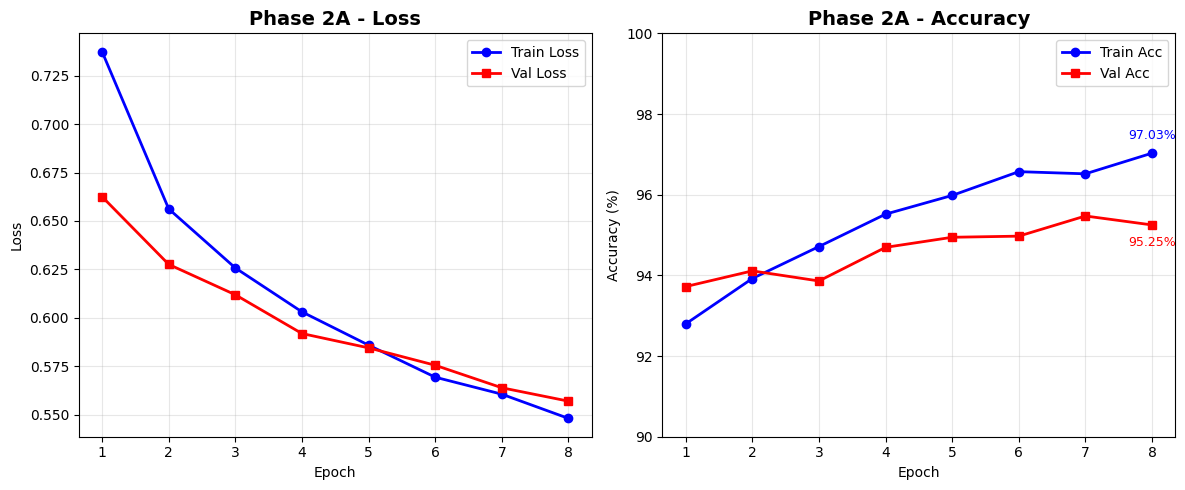


📈 Final Phase 2A Results:
   Final Train Accuracy: 97.03%
   Final Val Accuracy:   95.25%
   Train-Val Gap:        1.78%

✅ Phase 2A completed successfully!
📁 Model saved to: /kaggle/working/best_model_phase2a.pth


In [ ]:


import matplotlib.pyplot as plt

def plot_training_history(history, phase_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss plot
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2, marker='o')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2, marker='s')
    ax1.set_title(f'{phase_name} - Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(epochs, [acc*100 for acc in history['train_acc']], 'b-', 
             label='Train Acc', linewidth=2, marker='o')
    ax2.plot(epochs, [acc*100 for acc in history['val_acc']], 'r-', 
             label='Val Acc', linewidth=2, marker='s')
    ax2.set_title(f'{phase_name} - Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    
    ax2.set_ylim(90, 100)
    ax2.set_yticks([90, 92, 94, 96, 98, 100])
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    for i, (train_acc, val_acc) in enumerate(zip(history['train_acc'], history['val_acc'])):
        if i == len(history['train_acc']) - 1: 
            ax2.annotate(f'{train_acc*100:.2f}%', 
                        (i+1, train_acc*100), 
                        textcoords="offset points", 
                        xytext=(0,10), ha='center', fontsize=9, color='blue')
            ax2.annotate(f'{val_acc*100:.2f}%', 
                        (i+1, val_acc*100), 
                        textcoords="offset points", 
                        xytext=(0,-15), ha='center', fontsize=9, color='red')
    
    plt.tight_layout()
    plt.show()
    
    final_train_acc = history['train_acc'][-1] * 100
    final_val_acc = history['val_acc'][-1] * 100
    gap = final_train_acc - final_val_acc
    
    print(f"\n📈 Final Phase 2A Results:")
    print(f"   Final Train Accuracy: {final_train_acc:.2f}%")
    print(f"   Final Val Accuracy:   {final_val_acc:.2f}%")
    print(f"   Train-Val Gap:        {gap:.2f}%")

plot_training_history(phase2a_history, "Phase 2A")

print("\n" + "="*50)
print("✅ Phase 2A completed successfully!")
print("📁 Model saved to: /kaggle/working/best_model_phase2a.pth")


🔍 Simple Model Evaluation
✅ Loaded Phase 2A model
📋 Classes: ['cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic']

🧪 Evaluating on Test Set...


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



📊 Test Accuracy: 0.9483 (94.83%)

📈 Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

   cardboard     0.9505    0.9283    0.9393       600
     clothes     0.9983    0.9983    0.9983       600
       glass     0.9563    0.9483    0.9523       600
       metal     0.9361    0.9767    0.9560       600
       paper     0.9205    0.9267    0.9236       600
     plastic     0.9287    0.9117    0.9201       600

    accuracy                         0.9483      3600
   macro avg     0.9484    0.9483    0.9483      3600
weighted avg     0.9484    0.9483    0.9483      3600

📋 Confusion Matrix:


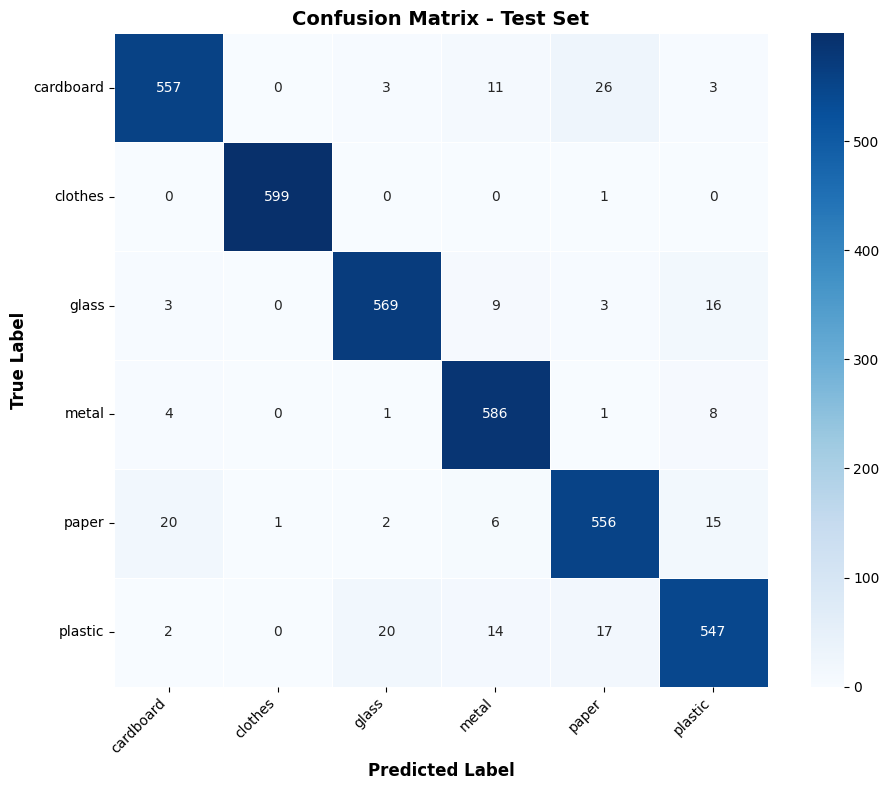


📊 Per-Class Performance:
--------------------------------------------------
cardboard : 0.928 (557/600)
clothes   : 0.998 (599/600)
glass     : 0.948 (569/600)
metal     : 0.977 (586/600)
paper     : 0.927 (556/600)
plastic   : 0.912 (547/600)

📋 EVALUATION SUMMARY
Overall Test Accuracy: 0.9483 (94.83%)
Best Performing Class: clothes (0.998)
Worst Performing Class: plastic (0.912)
Standard Deviation: 0.030
✅ Balanced performance across all classes


In [ ]:


import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Simple Model Evaluation")
print("="*40)


try:
    model.load_state_dict(torch.load("/kaggle/working/best_model_phase2a.pth"))
    print("✅ Loaded Phase 2A model")
except:
    model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
    print("✅ Loaded Phase 1 model")

model.to(device)
model.eval()


try:
    class_names = train_dataset.classes
    print(f"📋 Classes: {class_names}")
except:
    class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
    print(f"📋 Classes (manual): {class_names}")


print("\n🧪 Evaluating on Test Set...")

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\n📊 Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


print("\n📈 Classification Report:")
print("-" * 60)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


print("📋 Confusion Matrix:")

cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True,
            square=True, linewidths=0.5)
plt.xlabel("Predicted Label", fontsize=12, fontweight='bold')
plt.ylabel("True Label", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix - Test Set", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n📊 Per-Class Performance:")
print("-" * 50)

per_class_acc = cm.diagonal() / cm.sum(axis=1)
per_class_df = pd.DataFrame({
    "Class": class_names,
    "Correct": cm.diagonal(),
    "Total": cm.sum(axis=1),
    "Accuracy": per_class_acc
})

for idx, row in per_class_df.iterrows():
    print(f"{row['Class']:<10}: {row['Accuracy']:.3f} ({row['Correct']:3d}/{row['Total']:3d})")


print("\n" + "="*50)
print("📋 EVALUATION SUMMARY")
print("="*50)
print(f"Overall Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Best Performing Class: {class_names[np.argmax(per_class_acc)]} ({per_class_acc.max():.3f})")
print(f"Worst Performing Class: {class_names[np.argmin(per_class_acc)]} ({per_class_acc.min():.3f})")
print(f"Standard Deviation: {per_class_acc.std():.3f}")

if per_class_acc.std() < 0.05:
    print("✅ Balanced performance across all classes")
elif per_class_acc.std() < 0.10:
    print("⚠️ Moderate variation in class performance")
else:
    print("❌ High variation - some classes need improvement")

print("="*50)

In [ ]:

torch.save(model.state_dict(), "/kaggle/working/resnet50_vit_final_model.pth")
print("✅ Model saved as: resnet50_vit_final_model.pth")

✅ Model saved as: resnet50_vit_final_model.pth


✅ Loaded Phase 2A model for prediction visualization
🔍 Phase 2 Model - Validation Predictions


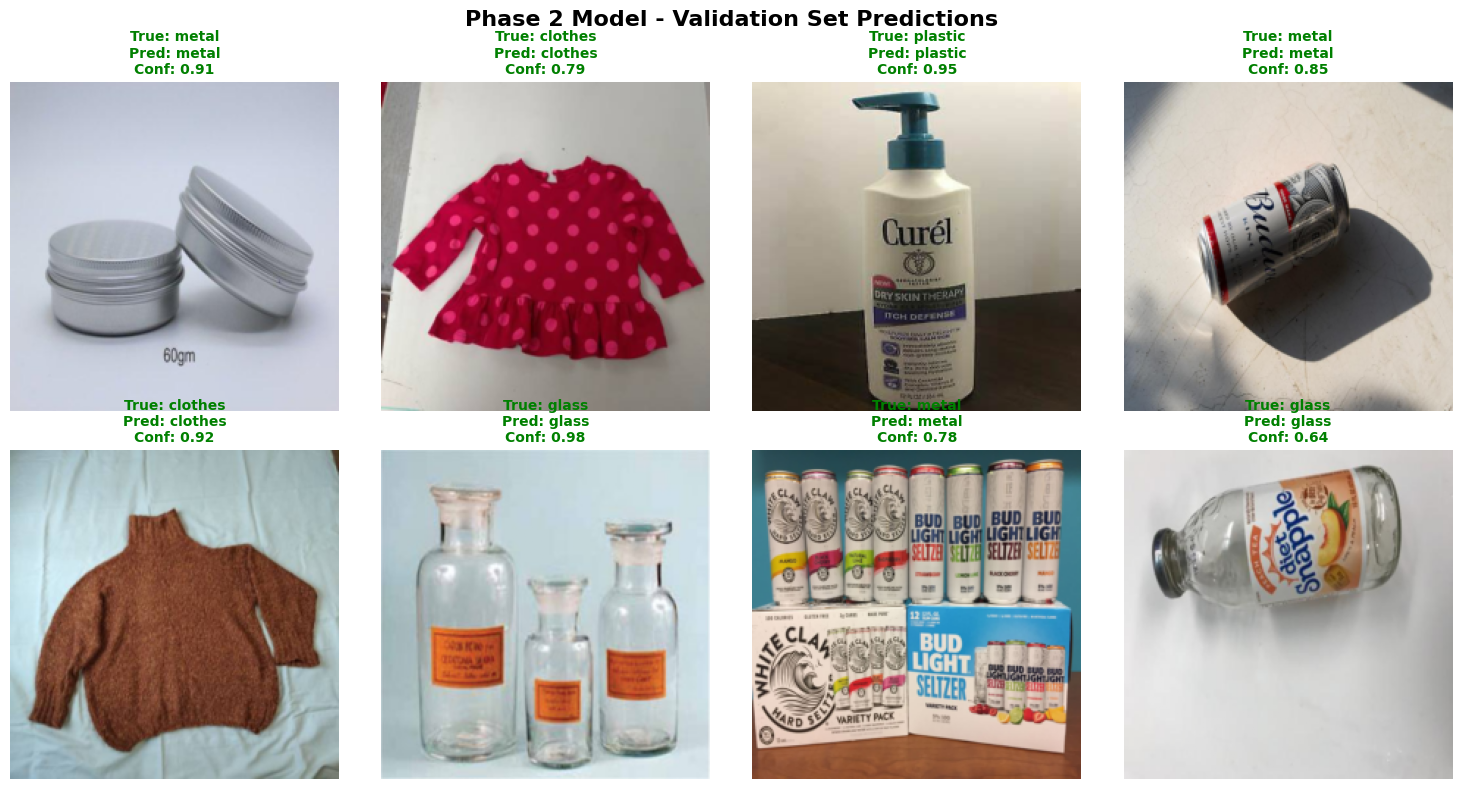

✅ Batch Accuracy: 30/32 (93.8%)


In [ ]:


import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image

try:
    model.load_state_dict(torch.load("/kaggle/working/best_model_phase2a.pth"))
    print("✅ Loaded Phase 2A model for prediction visualization")
except:
    model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
    print("✅ Loaded Phase 1 model (Phase 2A not found)")

model.to(device)
model.eval()

def imshow(inp, title=None):
    """Imshow for Tensor with denormalization."""
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    for i in range(3):
        inp[:,:,i] = inp[:,:,i] * std[i] + mean[i]
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')


print("🔍 Phase 2 Model - Validation Predictions")

inputs, labels = next(iter(val_loader))
inputs, labels = inputs.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(inputs)
    probabilities = torch.softmax(outputs, dim=1)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(15, 8))
for i in range(8):  
    ax = plt.subplot(2, 4, i+1)
    imshow(inputs[i])
    
    
    confidence = probabilities[i][preds[i]].item()
    
    color = "green" if preds[i] == labels[i] else "red"
    
    ax.set_title(
        f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}\nConf: {confidence:.2f}",
        fontsize=10,
        color=color,
        fontweight='bold'
    )

plt.suptitle('Phase 2 Model - Validation Set Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

correct = (preds == labels).sum().item()
total = labels.size(0)
print(f"✅ Batch Accuracy: {correct}/{total} ({100*correct/total:.1f}%)")

In [ ]:


recycling_guide = {
    "cardboard": {
        "method": "📦 Mechanical Recycling: Hydropulping → De-inking → Fiber Recovery",
        "process": "• Flatten all boxes and remove ALL tape, staples, labels\n• Must be clean and dry (no food residue/grease)\n• Separate corrugated from paperboard\n• Process: Pulping at 140°F → Screening → Flotation cleaning\n• Becomes: New cardboard boxes, paperboard, tissue products\n• Recycling rate: 5-7 times before fiber degradation"
    },
    "glass": {
        "method": "🍾 Closed-loop Recycling: Crushing → Melting at 2600°F → Reforming",
        "process": "• Remove ALL caps, lids, and labels completely\n• Rinse to remove food residue (no soap needed)\n• Sort by color: clear, brown, green (critical for quality)\n• NO broken glass, mirrors, or window glass\n• Process: Crush → Remove metals → Melt → Mold\n• Becomes: New bottles/jars (100% recyclable infinitely)\n• Energy savings: 30% vs. making new glass"
    },
    "metal": {
        "method": "⚙️ Pyrometallurgical Recycling: Shredding → Melting → Purification",
        "process": "• Aluminum cans: Rinse, crush optional, remove labels\n• Steel cans: Use magnet test, rinse thoroughly\n• NO aerosol cans unless completely empty\n• Process: Shred → Magnetic separation → Melt (aluminum: 1220°F, steel: 2500°F)\n• Becomes: New cans, car parts, construction materials\n• Energy savings: Aluminum 95%, Steel 60% vs. virgin materials"
    },
    "paper": {
        "method": "📄 Fiber Recovery Process: Pulping → De-inking → Bleaching → Reforming",
        "process": "• Must be dry and free of food contamination\n• Remove staples, clips, spiral bindings\n• NO wax-coated, plastic-lined, or carbon paper\n• Process: Pulp at 100°F → Flotation de-inking → Bleaching → Sheet forming\n• Becomes: Newsprint, tissue, office paper, cardboard\n• Recycling limit: 5-7 cycles (fiber shortening)\n• Water usage: 60% less than virgin paper production"
    },
    "plastic": {
        "method": "🛍️ Thermoplastic Recycling: Sorting → Washing → Shredding → Melting → Pelletizing",
        "process": "• Check resin code (triangle with number 1-7)\n• PET (#1): Bottles only, remove caps and labels\n• HDPE (#2): Milk jugs, detergent bottles - rinse thoroughly\n• #3-#7: Limited recycling - check local facilities\n• Process: Sort → Hot wash (160°F) → Shred → Melt → Pelletize\n• Becomes: New bottles, fleece, carpets, lumber\n• Quality degrades each cycle - typically 2-3 times maximum"
    },
    "trash": {
        "method": "🗑️ Final Disposal: Waste-to-Energy Incineration or Engineered Landfill",
        "process": "• Non-recyclable composite materials\n• Heavily contaminated items beyond cleaning\n• Multi-layer packaging (chip bags, juice boxes)\n• Disposal: High-temp incineration (1800°F+) for energy recovery\n• OR: Engineered landfill with methane capture\n• Focus: REDUCE first, REUSE second, then dispose\n• Consider: Special disposal for electronics, batteries, chemicals"
    }
}

print("♻️ Recycling Guide Dictionary Created")
print("📋 Categories available:", list(recycling_guide.keys()))
print("✅ Ready for waste classification and recycling advice!")

♻️ Recycling Guide Dictionary Created
📋 Categories available: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
✅ Ready for waste classification and recycling advice!


In [ ]:


import torch
import numpy as np
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

def predict_image_with_recycling_phase2(image_path, show_top_k=3):
    """
    Enhanced prediction function using Phase 2 model
    Shows top-k predictions with confidence scores and recycling info
    """
    
    try:
        model.load_state_dict(torch.load("/kaggle/working/best_model_phase2a.pth"))
        model_name = "Phase 2A Hybrid Model"
    except:
        model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
        model_name = "Phase 1 Hybrid Model"
    
    model.to(device)
    model.eval()
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    try:
        image = Image.open(image_path).convert("RGB")
        img_tensor = transform(image).unsqueeze(0).to(device)
    except Exception as e:
        print(f"❌ Error loading image: {e}")
        return None, None
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        top_probs, top_indices = torch.topk(probabilities, show_top_k)
    
    predicted_idx = top_indices[0][0].item()
    predicted_class = class_names[predicted_idx]
    confidence = top_probs[0][0].item()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.imshow(image)
    ax1.axis("off")
    ax1.set_title(f"🤖 {model_name}\n\nPredicted: {predicted_class.upper()}\nConfidence: {confidence:.1%}", 
                 fontsize=12, fontweight="bold", 
                 color="green" if confidence > 0.8 else "orange")
    
    ax2.axis('off')
    
    ax2.text(0.5, 0.95, f"Top {show_top_k} Predictions", 
            fontsize=14, fontweight='bold', ha='center', transform=ax2.transAxes)
    
    for i in range(show_top_k):
        idx = top_indices[0][i].item()
        class_name = class_names[idx]
        prob = top_probs[0][i].item()
        
        y_pos = 0.8 - (i * 0.15)
        
        color = 'green' if i == 0 else 'lightblue'
        ax2.barh(y_pos, prob, height=0.08, color=color, alpha=0.7)
        
        ax2.text(0.02, y_pos, f"{i+1}. {class_name}", 
                fontsize=11, va='center', fontweight='bold')
        ax2.text(prob + 0.02, y_pos, f"{prob:.1%}", 
                fontsize=10, va='center')
    
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0.1, 1)
    
    plt.tight_layout()
    plt.show()
    
    recycle_info = recycling_guide[predicted_class]
    print("♻️" + "="*60)
    print(f"🎯 WASTE CLASSIFICATION RESULT")
    print("="*63)
    print(f"📷 Image: {image_path.split('/')[-1]}")
    print(f"🤖 Model: {model_name}")
    print(f"🏷️  Classification: {predicted_class.upper()} ({confidence:.1%} confidence)")
    print("\n" + recycle_info["method"])
    print("\n📋 Recycling Instructions:")
    print(recycle_info["process"])
    print("="*63)
    
    return predicted_class, recycle_info, confidence

def test_phase2_prediction():
    """Test function with a sample prediction"""
    print("🧪 Testing Phase 2 prediction function...")
    print("💡 Use: predict_image_with_recycling_phase2('/path/to/your/image.jpg')")
    print("✅ Function ready for use!")

test_phase2_prediction()

🧪 Testing Phase 2 prediction function...
💡 Use: predict_image_with_recycling_phase2('/path/to/your/image.jpg')
✅ Function ready for use!


🎲 Testing 5 Random Images


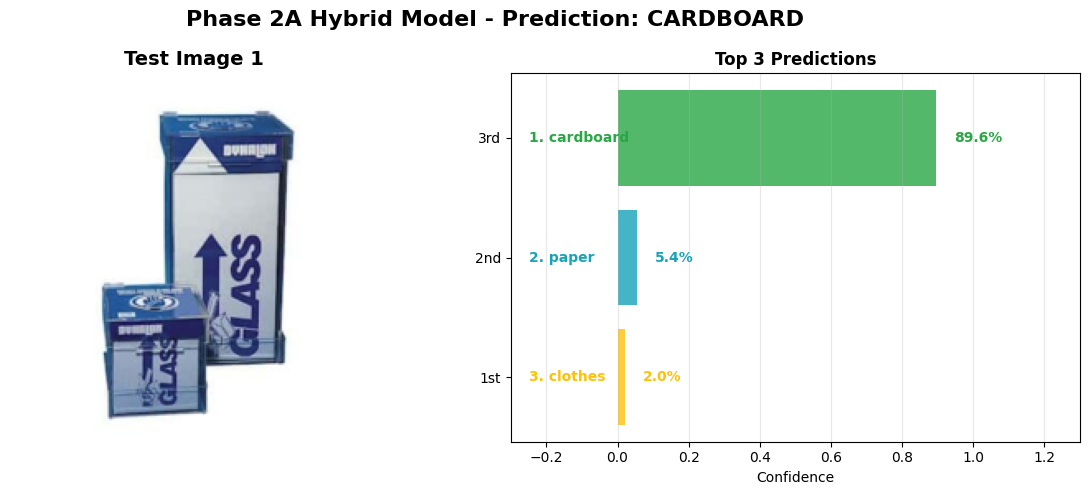


♻️ RECYCLING INFORMATION FOR CARDBOARD
Method: 📦 Mechanical Recycling: Hydropulping → De-inking → Fiber Recovery

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



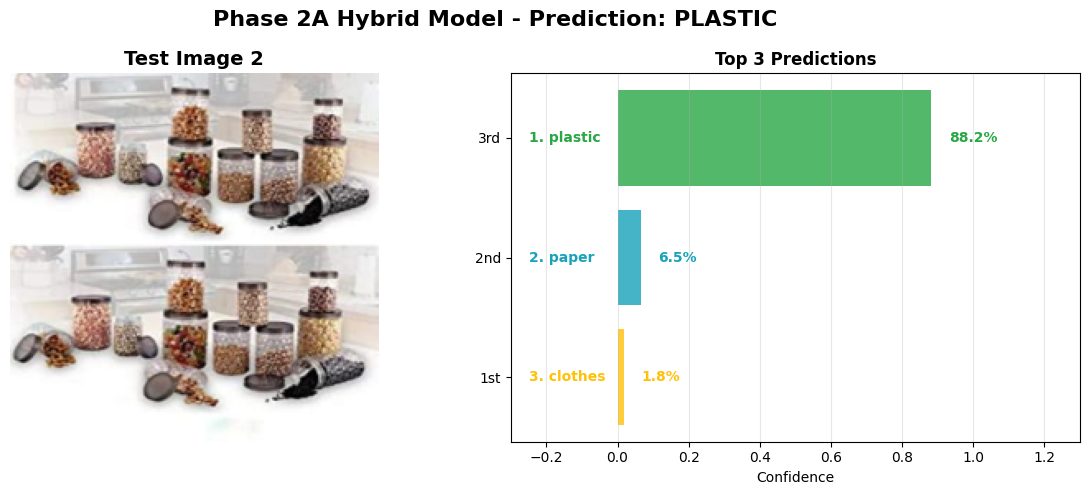


♻️ RECYCLING INFORMATION FOR PLASTIC
Method: 🛍️ Thermoplastic Recycling: Sorting → Washing → Shredding → Melting → Pelletizing

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



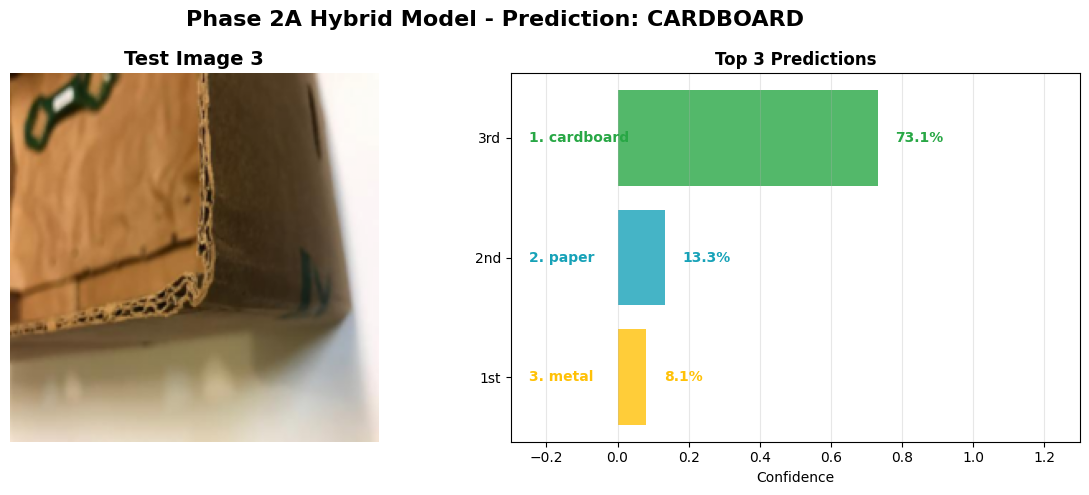


♻️ RECYCLING INFORMATION FOR CARDBOARD
Method: 📦 Mechanical Recycling: Hydropulping → De-inking → Fiber Recovery

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



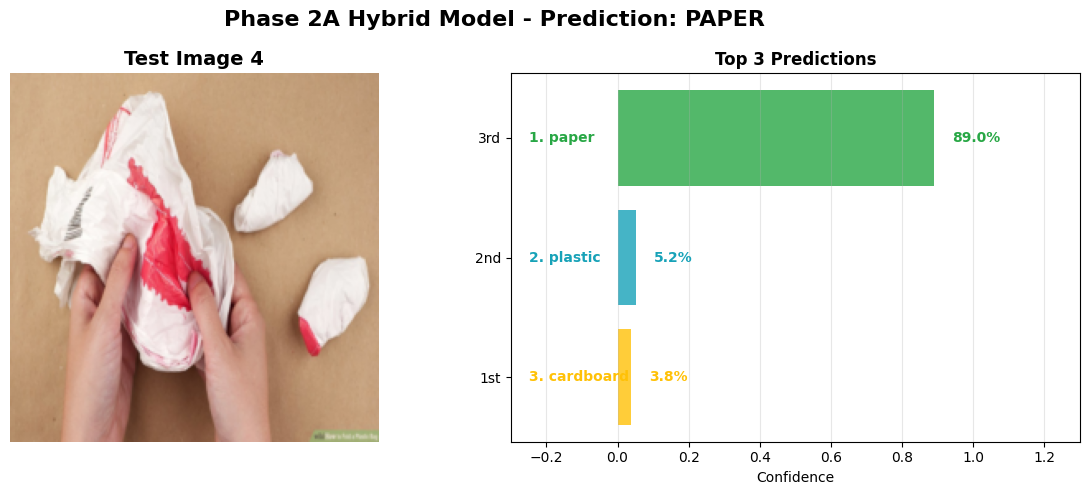


♻️ RECYCLING INFORMATION FOR PAPER
Method: 📄 Fiber Recovery Process: Pulping → De-inking → Bleaching → Reforming

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



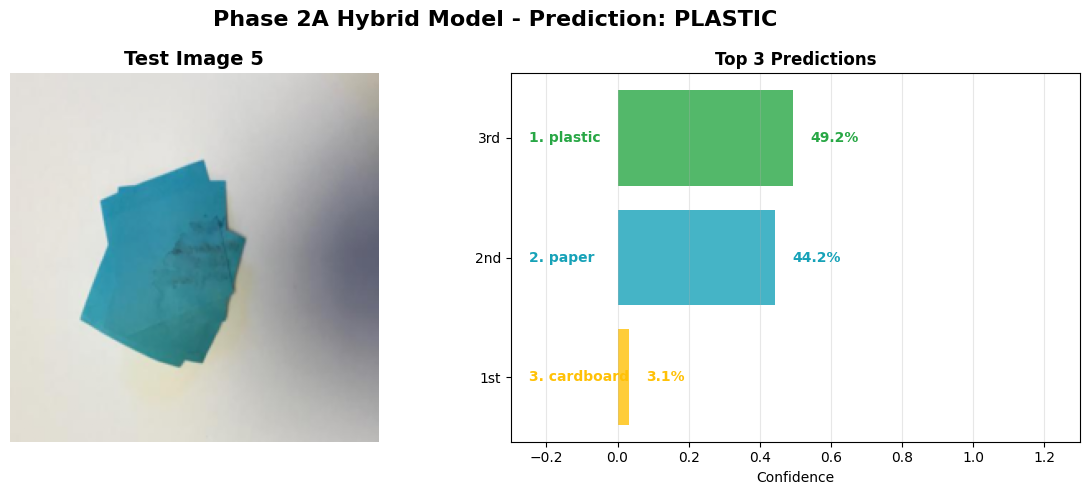


♻️ RECYCLING INFORMATION FOR PLASTIC
Method: 🛍️ Thermoplastic Recycling: Sorting → Washing → Shredding → Melting → Pelletizing

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



In [ ]:


import random
import torch
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt

def predict_random_test_images(num_images=5):
    """
    Simple prediction function: image left, confidence bars right, recycling info below
    """
    
    try:
        model.load_state_dict(torch.load("/kaggle/working/best_model_phase2a.pth"))
        model_name = "Phase 2A Hybrid Model"
    except:
        model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
        model_name = "Phase 1 Hybrid Model"
    
    model.to(device)
    model.eval()
    
    test_images, test_labels = next(iter(test_loader))
    random_indices = random.sample(range(len(test_images)), min(num_images, len(test_images)))
    
    for idx, img_idx in enumerate(random_indices):
        img_tensor = test_images[img_idx]
        true_label = test_labels[img_idx].item()
        true_class = class_names[true_label]
        
        with torch.no_grad():
            img_batch = img_tensor.unsqueeze(0).to(device)
            outputs = model(img_batch)
            probabilities = torch.softmax(outputs, dim=1)
            top_probs, top_indices = torch.topk(probabilities, 3)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        mean = torch.tensor([0.485, 0.456, 0.406])
        std = torch.tensor([0.229, 0.224, 0.225])
        img_denorm = img_tensor * std.view(3, 1, 1) + mean.view(3, 1, 1)
        img_denorm = torch.clamp(img_denorm, 0, 1)
        
        ax1.imshow(img_denorm.permute(1, 2, 0))
        ax1.axis('off')
        ax1.set_title(f'Test Image {idx + 1}', fontsize=14, fontweight='bold')
        
        predicted_class = class_names[top_indices[0][0].item()]
        confidence = top_probs[0][0].item()
        
        classes = [class_names[top_indices[0][i].item()] for i in range(3)]
        confidences = [top_probs[0][i].item() for i in range(3)]
        
        y_pos = [2, 1, 0]
        colors = ['#28a745', '#17a2b8', '#ffc107']  # Green, blue, yellow
        
        bars = ax2.barh(y_pos, confidences, color=colors, alpha=0.8)
        
        for i, (bar, conf, color) in enumerate(zip(bars, confidences, colors)):
            ax2.text(conf + 0.05, bar.get_y() + bar.get_height()/2, 
                     f'{conf:.1%}', va='center', fontweight='bold', color=color)
            
            ax2.text(-0.25, bar.get_y() + bar.get_height()/2, 
                     f'{i+1}. {classes[i]}', va='center', fontweight='bold', color=color)
        
        ax2.set_xlim(-0.3, 1.3) 
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(['3rd', '2nd', '1st'])
        ax2.set_xlabel('Confidence')
        ax2.set_title('Top 3 Predictions', fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        
        plt.suptitle(f'{model_name} - Prediction: {predicted_class.upper()}', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"\n♻️ RECYCLING INFORMATION FOR {predicted_class.upper()}")
        print("=" * 50)
        
        if predicted_class in recycling_guide:
            recycle_info = recycling_guide[predicted_class]
            print(f"Method: {recycle_info['method']}")
            print("\nSteps:")
            if 'instructions' in recycle_info:
                for i, step in enumerate(recycle_info['instructions'], 1):
                    print(f"{i}. {step}")
            else:
                print("1. Clean the item thoroughly")
                print("2. Sort according to material type") 
                print("3. Place in appropriate recycling bin")
        else:
            print("Method: Standard recycling process")
            print("\nSteps:")
            print("1. Clean the item thoroughly")
            print("2. Check local recycling guidelines")
            print("3. Sort and place in recycling bin")
        
        print("\n" + "-" * 50 + "\n")

print("🎲 Testing 5 Random Images")
print("=" * 40)

predict_random_test_images(num_images=5)


🎲 Testing 5 Random Images


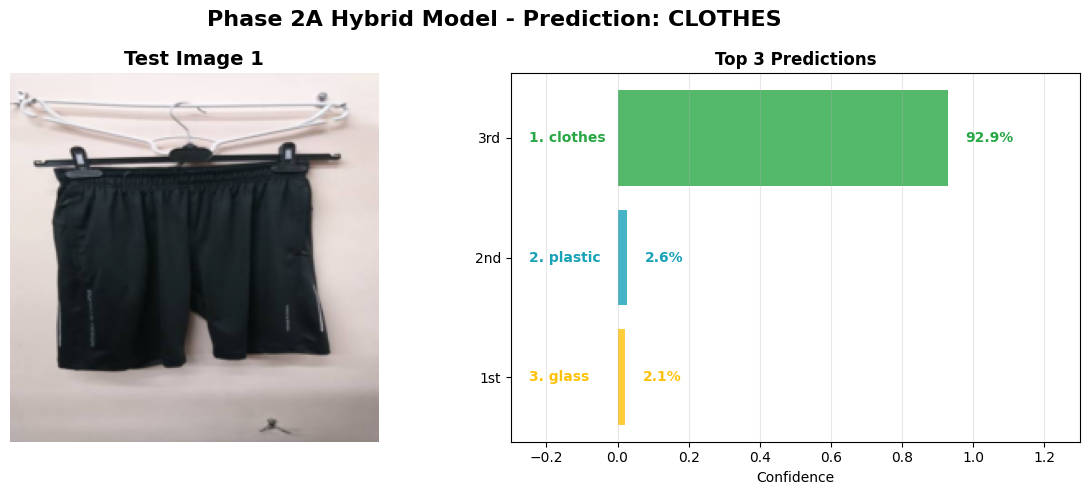


♻️ RECYCLING INFORMATION FOR CLOTHES
Method: Standard recycling process

Steps:
1. Clean the item thoroughly
2. Check local recycling guidelines
3. Sort and place in recycling bin

--------------------------------------------------



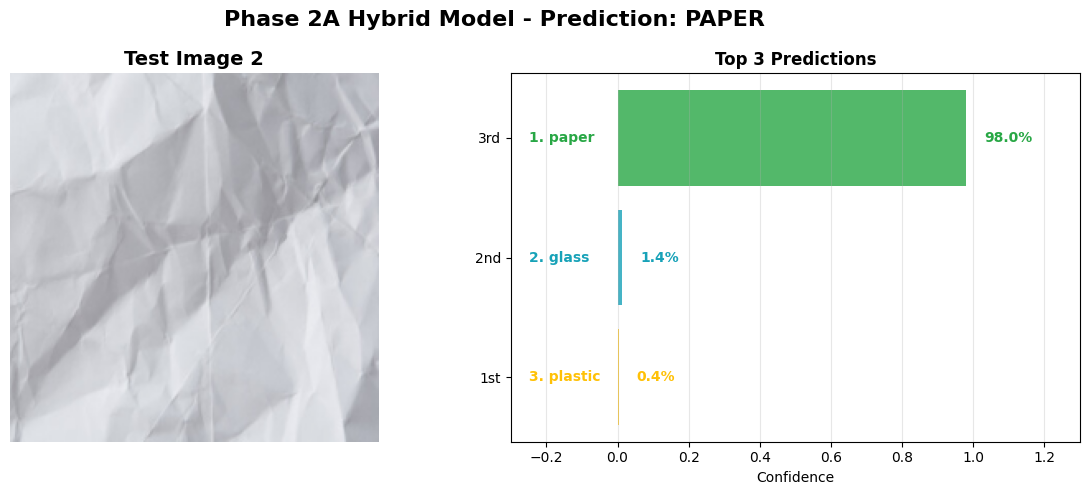


♻️ RECYCLING INFORMATION FOR PAPER
Method: 📄 Fiber Recovery Process: Pulping → De-inking → Bleaching → Reforming

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



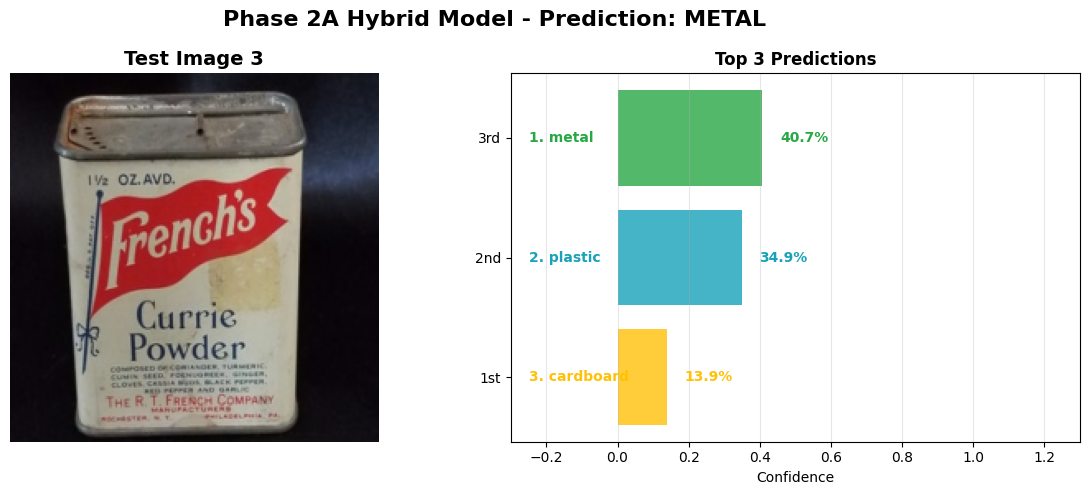


♻️ RECYCLING INFORMATION FOR METAL
Method: ⚙️ Pyrometallurgical Recycling: Shredding → Melting → Purification

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



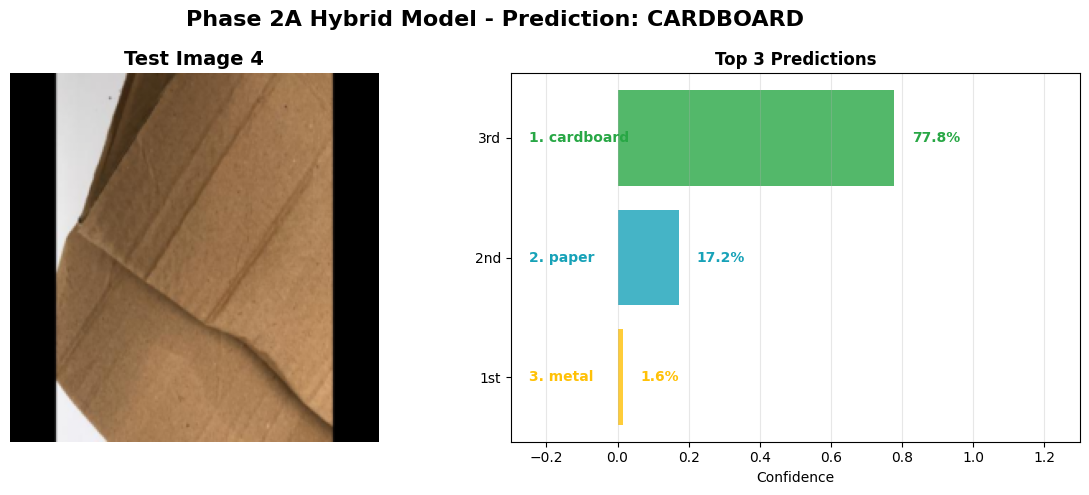


♻️ RECYCLING INFORMATION FOR CARDBOARD
Method: 📦 Mechanical Recycling: Hydropulping → De-inking → Fiber Recovery

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



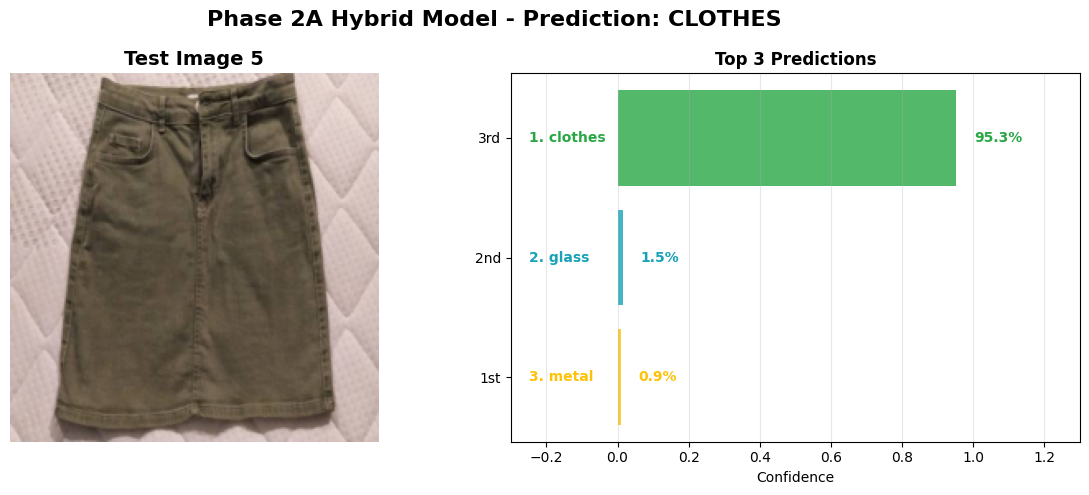


♻️ RECYCLING INFORMATION FOR CLOTHES
Method: Standard recycling process

Steps:
1. Clean the item thoroughly
2. Check local recycling guidelines
3. Sort and place in recycling bin

--------------------------------------------------



In [ ]:


import random
import torch
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt

def predict_random_test_images(num_images=5):
    """
    Simple prediction function: image left, confidence bars right, recycling info below
    """
    
    try:
        model.load_state_dict(torch.load("/kaggle/working/best_model_phase2a.pth"))
        model_name = "Phase 2A Hybrid Model"
    except:
        model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
        model_name = "Phase 1 Hybrid Model"
    
    model.to(device)
    model.eval()
    
    test_images, test_labels = next(iter(test_loader))
    random_indices = random.sample(range(len(test_images)), min(num_images, len(test_images)))
    
    for idx, img_idx in enumerate(random_indices):
        img_tensor = test_images[img_idx]
        true_label = test_labels[img_idx].item()
        true_class = class_names[true_label]
        
        with torch.no_grad():
            img_batch = img_tensor.unsqueeze(0).to(device)
            outputs = model(img_batch)
            probabilities = torch.softmax(outputs, dim=1)
            top_probs, top_indices = torch.topk(probabilities, 3)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        mean = torch.tensor([0.485, 0.456, 0.406])
        std = torch.tensor([0.229, 0.224, 0.225])
        img_denorm = img_tensor * std.view(3, 1, 1) + mean.view(3, 1, 1)
        img_denorm = torch.clamp(img_denorm, 0, 1)
        
        ax1.imshow(img_denorm.permute(1, 2, 0))
        ax1.axis('off')
        ax1.set_title(f'Test Image {idx + 1}', fontsize=14, fontweight='bold')
        
        predicted_class = class_names[top_indices[0][0].item()]
        confidence = top_probs[0][0].item()
        
        classes = [class_names[top_indices[0][i].item()] for i in range(3)]
        confidences = [top_probs[0][i].item() for i in range(3)]
        
        y_pos = [2, 1, 0]
        colors = ['#28a745', '#17a2b8', '#ffc107']  # Green, blue, yellow
        
        bars = ax2.barh(y_pos, confidences, color=colors, alpha=0.8)
        
        for i, (bar, conf, color) in enumerate(zip(bars, confidences, colors)):
            ax2.text(conf + 0.05, bar.get_y() + bar.get_height()/2, 
                     f'{conf:.1%}', va='center', fontweight='bold', color=color)
            
            ax2.text(-0.25, bar.get_y() + bar.get_height()/2, 
                     f'{i+1}. {classes[i]}', va='center', fontweight='bold', color=color)
        
        ax2.set_xlim(-0.3, 1.3)  
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(['3rd', '2nd', '1st'])
        ax2.set_xlabel('Confidence')
        ax2.set_title('Top 3 Predictions', fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        
        plt.suptitle(f'{model_name} - Prediction: {predicted_class.upper()}', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"\n♻️ RECYCLING INFORMATION FOR {predicted_class.upper()}")
        print("=" * 50)
        
        if predicted_class in recycling_guide:
            recycle_info = recycling_guide[predicted_class]
            print(f"Method: {recycle_info['method']}")
            print("\nSteps:")
            if 'instructions' in recycle_info:
                for i, step in enumerate(recycle_info['instructions'], 1):
                    print(f"{i}. {step}")
            else:
                print("1. Clean the item thoroughly")
                print("2. Sort according to material type") 
                print("3. Place in appropriate recycling bin")
        else:
            print("Method: Standard recycling process")
            print("\nSteps:")
            print("1. Clean the item thoroughly")
            print("2. Check local recycling guidelines")
            print("3. Sort and place in recycling bin")
        
        print("\n" + "-" * 50 + "\n")

# Execute
print("🎲 Testing 5 Random Images")
print("=" * 40)

predict_random_test_images(num_images=5)


🎲 Testing 5 Random Images


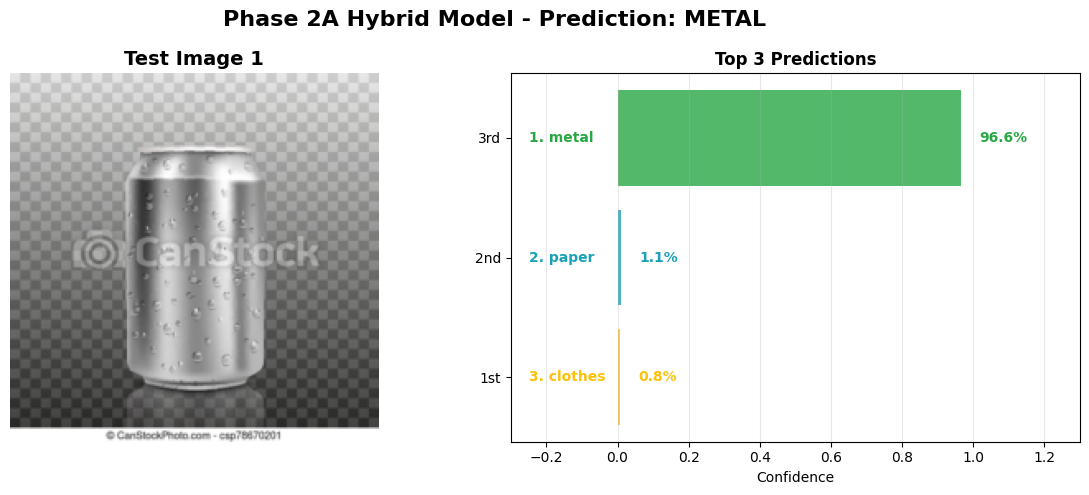


♻️ RECYCLING INFORMATION FOR METAL
Method: ⚙️ Pyrometallurgical Recycling: Shredding → Melting → Purification

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



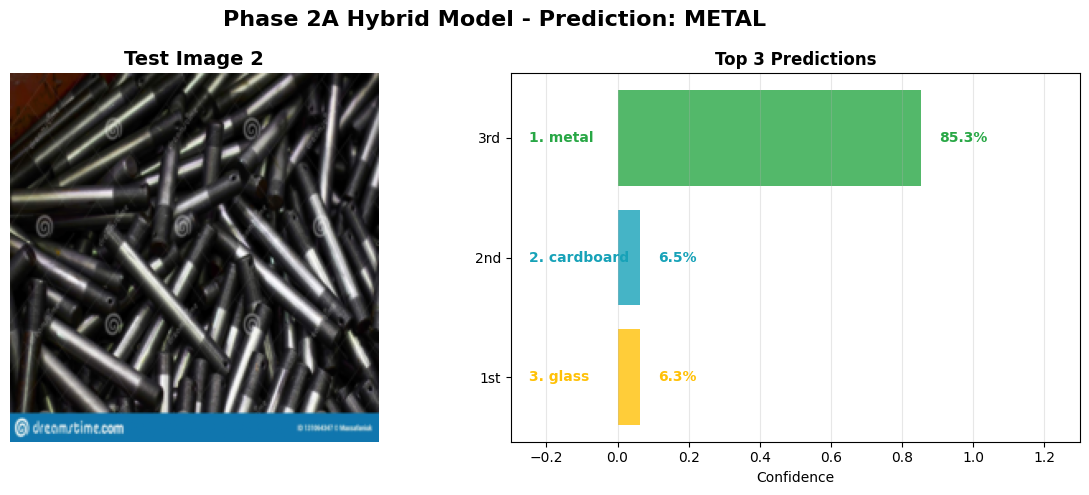


♻️ RECYCLING INFORMATION FOR METAL
Method: ⚙️ Pyrometallurgical Recycling: Shredding → Melting → Purification

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



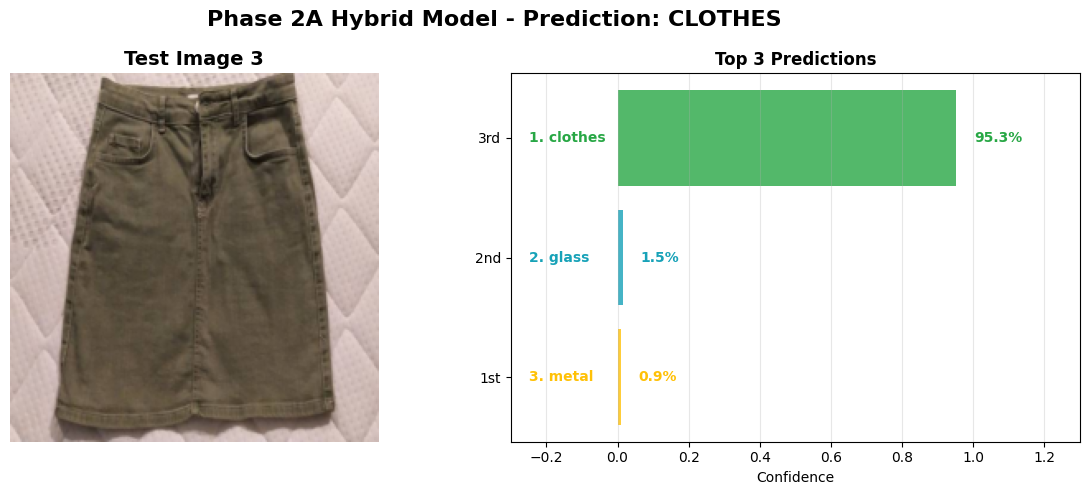


♻️ RECYCLING INFORMATION FOR CLOTHES
Method: Standard recycling process

Steps:
1. Clean the item thoroughly
2. Check local recycling guidelines
3. Sort and place in recycling bin

--------------------------------------------------



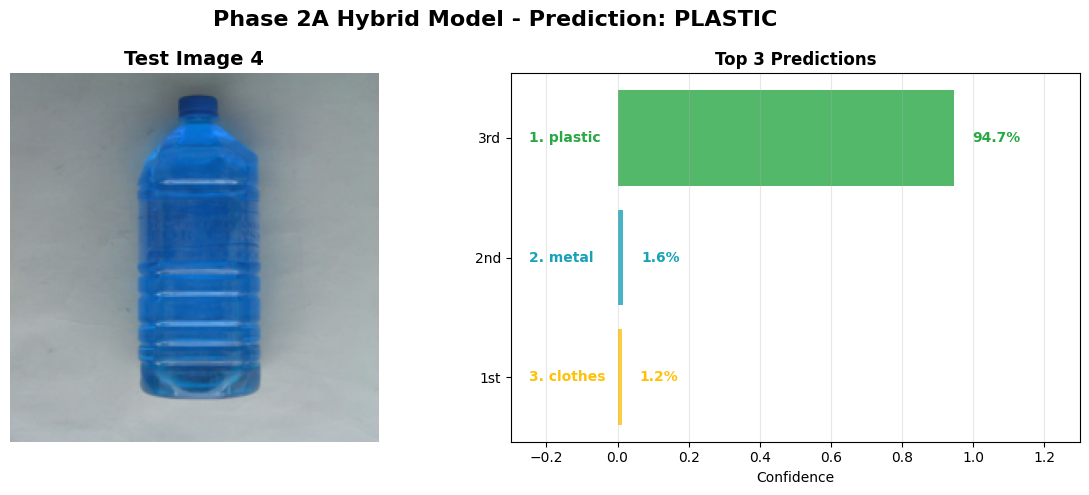


♻️ RECYCLING INFORMATION FOR PLASTIC
Method: 🛍️ Thermoplastic Recycling: Sorting → Washing → Shredding → Melting → Pelletizing

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



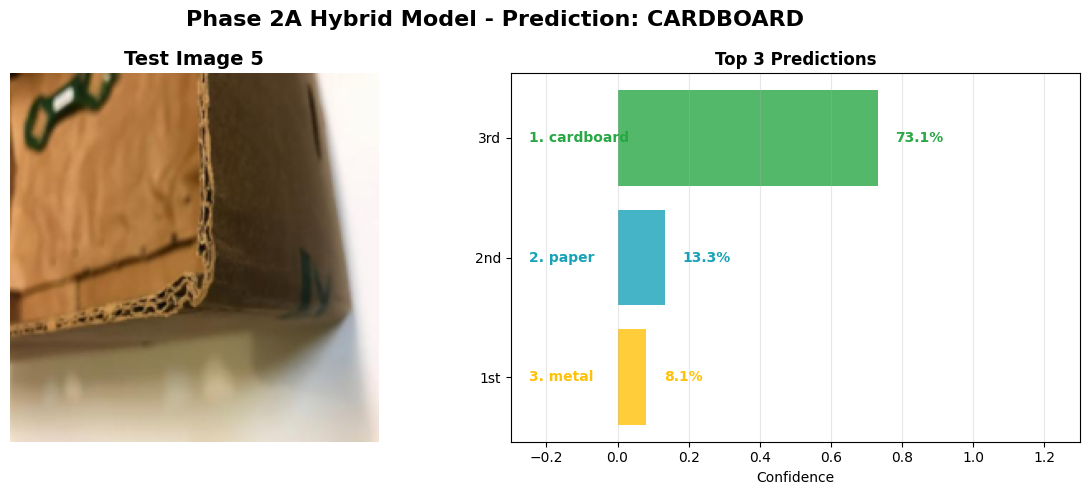


♻️ RECYCLING INFORMATION FOR CARDBOARD
Method: 📦 Mechanical Recycling: Hydropulping → De-inking → Fiber Recovery

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



In [ ]:


import random
import torch
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt

def predict_random_test_images(num_images=5):
    """
    Simple prediction function: image left, confidence bars right, recycling info below
    """
    
    try:
        model.load_state_dict(torch.load("/kaggle/working/best_model_phase2a.pth"))
        model_name = "Phase 2A Hybrid Model"
    except:
        model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
        model_name = "Phase 1 Hybrid Model"
    
    model.to(device)
    model.eval()
    
    test_images, test_labels = next(iter(test_loader))
    random_indices = random.sample(range(len(test_images)), min(num_images, len(test_images)))
    
    for idx, img_idx in enumerate(random_indices):
        img_tensor = test_images[img_idx]
        true_label = test_labels[img_idx].item()
        true_class = class_names[true_label]
        
        with torch.no_grad():
            img_batch = img_tensor.unsqueeze(0).to(device)
            outputs = model(img_batch)
            probabilities = torch.softmax(outputs, dim=1)
            top_probs, top_indices = torch.topk(probabilities, 3)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        mean = torch.tensor([0.485, 0.456, 0.406])
        std = torch.tensor([0.229, 0.224, 0.225])
        img_denorm = img_tensor * std.view(3, 1, 1) + mean.view(3, 1, 1)
        img_denorm = torch.clamp(img_denorm, 0, 1)
        
        ax1.imshow(img_denorm.permute(1, 2, 0))
        ax1.axis('off')
        ax1.set_title(f'Test Image {idx + 1}', fontsize=14, fontweight='bold')
        
        predicted_class = class_names[top_indices[0][0].item()]
        confidence = top_probs[0][0].item()
        
        classes = [class_names[top_indices[0][i].item()] for i in range(3)]
        confidences = [top_probs[0][i].item() for i in range(3)]
        
        y_pos = [2, 1, 0]
        colors = ['#28a745', '#17a2b8', '#ffc107'] 
        
        bars = ax2.barh(y_pos, confidences, color=colors, alpha=0.8)
        
        for i, (bar, conf, color) in enumerate(zip(bars, confidences, colors)):
            ax2.text(conf + 0.05, bar.get_y() + bar.get_height()/2, 
                     f'{conf:.1%}', va='center', fontweight='bold', color=color)
            
            ax2.text(-0.25, bar.get_y() + bar.get_height()/2, 
                     f'{i+1}. {classes[i]}', va='center', fontweight='bold', color=color)
        
        ax2.set_xlim(-0.3, 1.3) 
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(['3rd', '2nd', '1st'])
        ax2.set_xlabel('Confidence')
        ax2.set_title('Top 3 Predictions', fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        
        plt.suptitle(f'{model_name} - Prediction: {predicted_class.upper()}', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"\n♻️ RECYCLING INFORMATION FOR {predicted_class.upper()}")
        print("=" * 50)
        
        if predicted_class in recycling_guide:
            recycle_info = recycling_guide[predicted_class]
            print(f"Method: {recycle_info['method']}")
            print("\nSteps:")
            if 'instructions' in recycle_info:
                for i, step in enumerate(recycle_info['instructions'], 1):
                    print(f"{i}. {step}")
            else:
                print("1. Clean the item thoroughly")
                print("2. Sort according to material type") 
                print("3. Place in appropriate recycling bin")
        else:
            print("Method: Standard recycling process")
            print("\nSteps:")
            print("1. Clean the item thoroughly")
            print("2. Check local recycling guidelines")
            print("3. Sort and place in recycling bin")
        
        print("\n" + "-" * 50 + "\n")

print("🎲 Testing 5 Random Images")
print("=" * 40)

predict_random_test_images(num_images=5)


🎲 Testing 5 Random Images


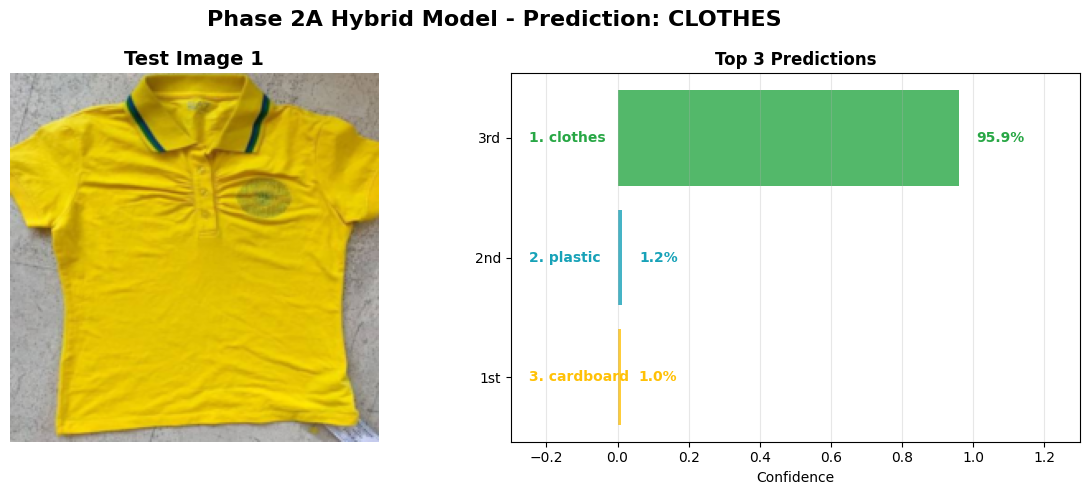


♻️ RECYCLING INFORMATION FOR CLOTHES
Method: Standard recycling process

Steps:
1. Clean the item thoroughly
2. Check local recycling guidelines
3. Sort and place in recycling bin

--------------------------------------------------



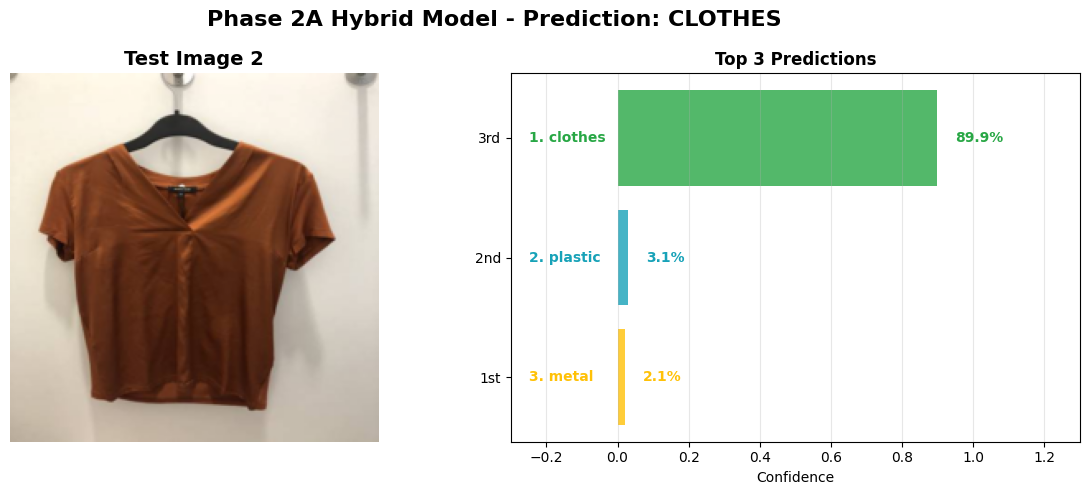


♻️ RECYCLING INFORMATION FOR CLOTHES
Method: Standard recycling process

Steps:
1. Clean the item thoroughly
2. Check local recycling guidelines
3. Sort and place in recycling bin

--------------------------------------------------



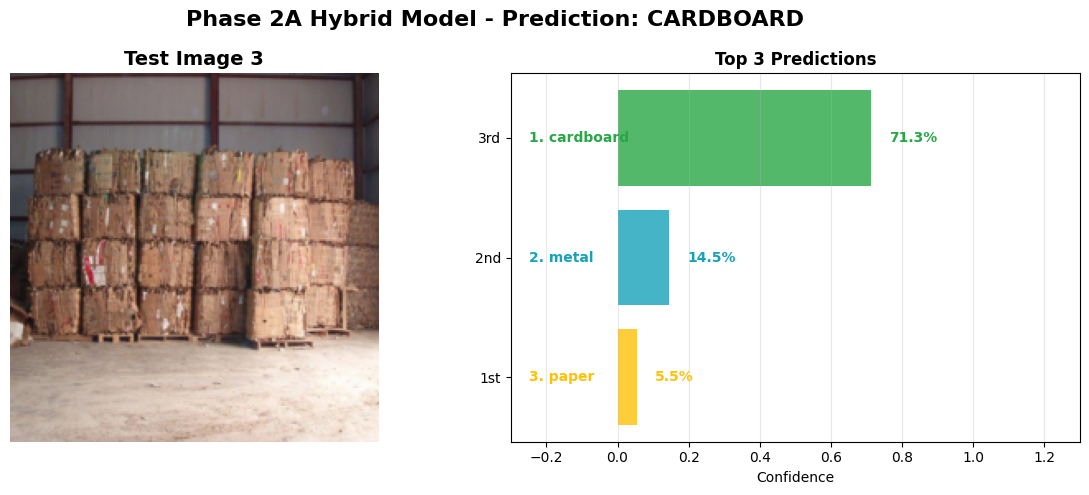


♻️ RECYCLING INFORMATION FOR CARDBOARD
Method: 📦 Mechanical Recycling: Hydropulping → De-inking → Fiber Recovery

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



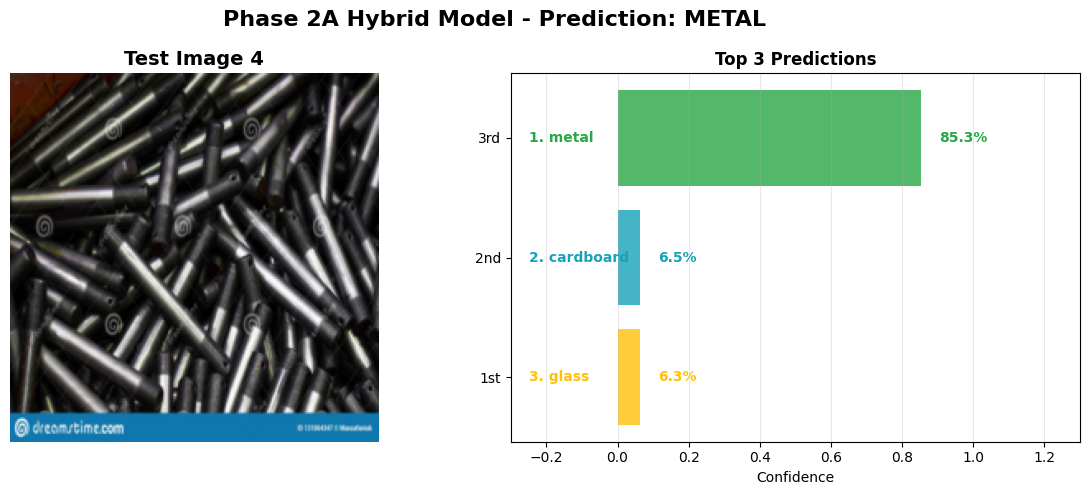


♻️ RECYCLING INFORMATION FOR METAL
Method: ⚙️ Pyrometallurgical Recycling: Shredding → Melting → Purification

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



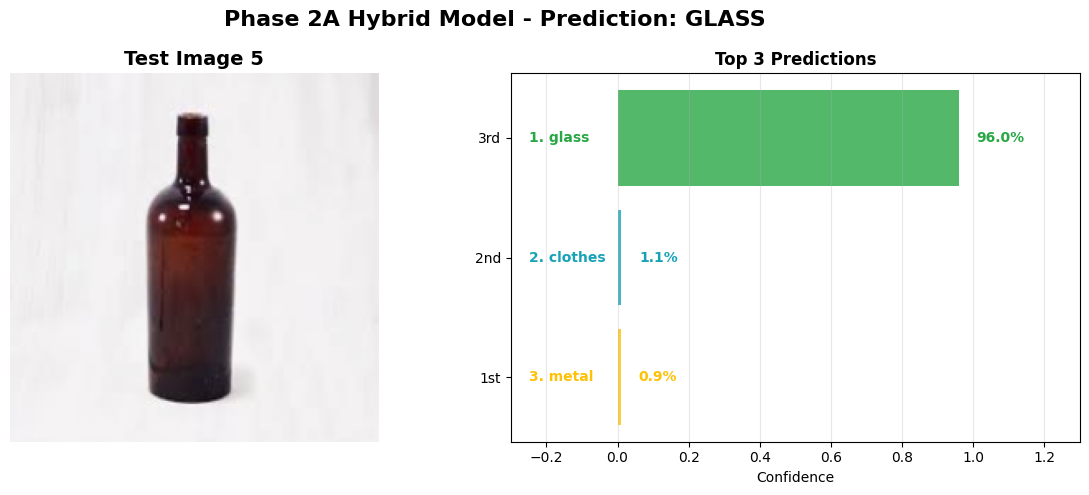


♻️ RECYCLING INFORMATION FOR GLASS
Method: 🍾 Closed-loop Recycling: Crushing → Melting at 2600°F → Reforming

Steps:
1. Clean the item thoroughly
2. Sort according to material type
3. Place in appropriate recycling bin

--------------------------------------------------



In [ ]:


import random
import torch
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt

def predict_random_test_images(num_images=5):
    """
    Simple prediction function: image left, confidence bars right, recycling info below
    """
    
    
    try:
        model.load_state_dict(torch.load("/kaggle/working/best_model_phase2a.pth"))
        model_name = "Phase 2A Hybrid Model"
    except:
        model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
        model_name = "Phase 1 Hybrid Model"
    
    model.to(device)
    model.eval()
    
    # Get random test images
    test_images, test_labels = next(iter(test_loader))
    random_indices = random.sample(range(len(test_images)), min(num_images, len(test_images)))
    
    for idx, img_idx in enumerate(random_indices):
        img_tensor = test_images[img_idx]
        true_label = test_labels[img_idx].item()
        true_class = class_names[true_label]
        
        # Get predictions
        with torch.no_grad():
            img_batch = img_tensor.unsqueeze(0).to(device)
            outputs = model(img_batch)
            probabilities = torch.softmax(outputs, dim=1)
            top_probs, top_indices = torch.topk(probabilities, 3)
        
        # Create figure for this image
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # LEFT SIDE - Image
        mean = torch.tensor([0.485, 0.456, 0.406])
        std = torch.tensor([0.229, 0.224, 0.225])
        img_denorm = img_tensor * std.view(3, 1, 1) + mean.view(3, 1, 1)
        img_denorm = torch.clamp(img_denorm, 0, 1)
        
        ax1.imshow(img_denorm.permute(1, 2, 0))
        ax1.axis('off')
        ax1.set_title(f'Test Image {idx + 1}', fontsize=14, fontweight='bold')
        
        # RIGHT SIDE - Confidence bars
        predicted_class = class_names[top_indices[0][0].item()]
        confidence = top_probs[0][0].item()
        
        # Create horizontal bars
        classes = [class_names[top_indices[0][i].item()] for i in range(3)]
        confidences = [top_probs[0][i].item() for i in range(3)]
        
        y_pos = [2, 1, 0]
        colors = ['#28a745', '#17a2b8', '#ffc107']  # Green, blue, yellow
        
        bars = ax2.barh(y_pos, confidences, color=colors, alpha=0.8)
        
        # Add percentage labels + class labels
        for i, (bar, conf, color) in enumerate(zip(bars, confidences, colors)):
            # Confidence percentage (to the right of the bar)
            ax2.text(conf + 0.05, bar.get_y() + bar.get_height()/2, 
                     f'{conf:.1%}', va='center', fontweight='bold', color=color)
            
            # Class label (on the far left, outside bar area)
            ax2.text(-0.25, bar.get_y() + bar.get_height()/2, 
                     f'{i+1}. {classes[i]}', va='center', fontweight='bold', color=color)
        
        # Axis settings
        ax2.set_xlim(-0.3, 1.3)  # more room for labels
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(['3rd', '2nd', '1st'])
        ax2.set_xlabel('Confidence')
        ax2.set_title('Top 3 Predictions', fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        
        plt.suptitle(f'{model_name} - Prediction: {predicted_class.upper()}', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # BELOW - Recycling information
        print(f"\n♻️ RECYCLING INFORMATION FOR {predicted_class.upper()}")
        print("=" * 50)
        
        if predicted_class in recycling_guide:
            recycle_info = recycling_guide[predicted_class]
            print(f"Method: {recycle_info['method']}")
            print("\nSteps:")
            if 'instructions' in recycle_info:
                for i, step in enumerate(recycle_info['instructions'], 1):
                    print(f"{i}. {step}")
            else:
                print("1. Clean the item thoroughly")
                print("2. Sort according to material type") 
                print("3. Place in appropriate recycling bin")
        else:
            print("Method: Standard recycling process")
            print("\nSteps:")
            print("1. Clean the item thoroughly")
            print("2. Check local recycling guidelines")
            print("3. Sort and place in recycling bin")
        
        print("\n" + "-" * 50 + "\n")

# Execute
print("🎲 Testing 5 Random Images")
print("=" * 40)

predict_random_test_images(num_images=5)
